# Predicting Antimicrobial Resistance Patterns in Kazakhstan Using Zero-Shot Machine Learning

This notebook implements a zero-shot machine learning framework to predict antimicrobial resistance (AMR) patterns in Kazakhstan using three global clinical surveillance databases enriched with macroeconomic indicators.

**Key design:** Kazakhstan is fully excluded from model training. The model generalizes to Kazakhstan using macroeconomic proxy features (GDP, health expenditure, population density), enabling zero-shot prediction in the absence of local clinical training data.

---

## Dataset Sources (Public Kaggle Datasets)

| Dataset | Description | Kaggle Path |
|---|---|---|
| ATLAS | Global AMR surveillance (Pfizer) | `/kaggle/input/atlas-csv/atlas.csv` |
| SIDERO-WT | Global AMR surveillance (Shionogi) | `/kaggle/input/ddddddd/sidero_wt.xlsx` |
| KEYSTONE | Global AMR surveillance | `/kaggle/input/ddddddd/keystone.xlsx` |
| World Bank Macro (Global) | GDP, health expenditure, population density | `/kaggle/input/datasets/uaisamangeldi/macrob/` |
| World Bank Macro (Kazakhstan) | Kazakhstan-specific macro indicators | `/kaggle/input/datasets/uaisamangeldi/macro-kz/` |
| Kazakhstan DID | Antibiotic consumption DDD per 1000/day (2017–2023) | `/kaggle/input/datasets/uaisamangeldi/kz-data/kazakhstan_antibiotics_did_2017_2023.csv` |

> ATLAS, SIDERO-WT, and KEYSTONE were obtained via formal data request through [vivli.org](https://vivli.org).
> World Bank indicators used: NY.GDP.PCAP.CD · SH.XPD.CHEX.GD.ZS · EN.POP.DNST

---

## Notebook Structure
1. Setup & Dependencies
2. Data Loading & Harmonization
3. Leakage Audit
4. Global Macroeconomic Feature Engineering
5. Feature Set Definition
6. Domain Split
7. Model Training (RF · XGBoost · LightGBM)
8. LOCO Validation
9. 5-Fold Time-Aware Cross-Validation
10. Kazakhstan Macroeconomic Data Processing
11. Zero-Shot Prediction for Kazakhstan
12. Results & Visualization


## 1. Setup & Dependencies

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
os.makedirs('/kaggle/working/', exist_ok=True)
print("Environment ready.")

Environment ready.


## 2. Data Loading & Harmonization

Three global AMR surveillance databases are loaded, standardized, and merged into a single unified dataset.

**Resistance encoding:**
- SIR: R=1, S=0, I=discarded (clinically ambiguous)
- MIC: binary via simplified CLSI/EUCAST breakpoints
- Unique isolate IDs: `{SOURCE}_{original_id}_{year}` to prevent cross-database collisions


In [2]:
ATLAS_PATH    = '/kaggle/input/datasets/user/atlas-csv/atlas.csv'
SIDERO_PATH   = '/kaggle/input/datasets/user/sidero-wt/sidero_wt.xlsx'
KEYSTONE_PATH = '/kaggle/input/datasets/user/keystone/keystone.xlsx'
COMBINED_OUTPUT = '/kaggle/working/combined_dataset.csv'

def parse_sir_to_binary(sir_str):
    """SIR → binary. Intermediate (I) discarded as clinically ambiguous."""
    if pd.isna(sir_str):
        return np.nan
    s = str(sir_str).strip().upper()
    if s in ['R', 'RESISTANT']:   return 1
    if s in ['S', 'SUSCEPTIBLE']: return 0
    return np.nan

def clean_mic_value(val):
    """Normalize MIC string to float."""
    if pd.isna(val): return np.nan
    val = str(val).strip().replace(',', '.')
    for sym in ['<=', '≤', '>=', '≥']:
        val = val.replace(sym, '')
    if '>' in val:
        try: return float(val.replace('>', '').strip()) + 0.0001
        except: return np.nan
    try: return float(val.strip())
    except: return np.nan

def parse_mic_to_binary(mic_val, antibiotic):
    """MIC → binary using simplified CLSI/EUCAST breakpoints."""
    mic = clean_mic_value(mic_val)
    if pd.isna(mic): return np.nan
    thresholds = {
        'Meropenem': 4, 'Imipenem': 4, 'Ceftazidime': 8,
        'Ciprofloxacin': 1, 'Colistin': 4, 'Amikacin': 16,
        'Gentamicin': 8, 'Cefepime': 8,
    }
    return 1 if mic > thresholds.get(antibiotic, 8) else 0

def assign_unique_isolate_id(df, data_source):
    """Composite isolate ID: {source}_{original_id}_{year} — prevents cross-database collisions."""
    if data_source == 'ATLAS' and 'Isolate Id' in df.columns:
        df['original_id'] = df['Isolate Id'].astype(str).str.strip()
    elif data_source == 'KEYSTONE' and 'Collection Number' in df.columns:
        df['original_id'] = df['Collection Number'].astype(str).str.strip()
    else:
        df['original_id'] = df.index.astype(str)
    df['isolate_id'] = data_source + '_' + df['original_id'] + '_' + df['year'].fillna(0).astype(int).astype(str)
    return df

def process_dataset(path, data_source, chunksize=250000):
    print(f"Processing {data_source}...")
    is_csv = path.endswith('.csv')
    reader = pd.read_csv if is_csv else pd.read_excel
    chunks = reader(path, chunksize=chunksize, low_memory=False) if is_csv else [reader(path)]
    processed = []

    for i, chunk in enumerate(chunks):
        print(f"  Chunk {i+1}: {len(chunk)} rows")
        rename = {
            'Isolate Id': 'original_id_temp', 'Species': 'organism',
            'Country': 'country', 'Year': 'year',
            'Organism Name': 'organism', 'Year Collected': 'year',
            'Organism': 'organism', 'Study Year': 'year',
            'Collection Number': 'original_id_temp',
        }
        chunk = chunk.rename(columns=rename)
        for col in ['country', 'year', 'organism']:
            if col not in chunk.columns:
                chunk[col] = 'Unknown' if col != 'year' else np.nan
        chunk['country']  = chunk['country'].astype(str).str.strip()
        chunk['organism'] = chunk['organism'].astype(str).str.strip()
        chunk['year']     = pd.to_numeric(chunk['year'], errors='coerce').astype('Int16')
        chunk = assign_unique_isolate_id(chunk, data_source)

        sir_cols = [c for c in chunk.columns if c.endswith('_I')]
        mic_cols = [c for c in chunk.columns if c not in
                    sir_cols + ['isolate_id', 'country', 'year', 'organism', 'original_id', 'original_id_temp']]
        value_vars   = sir_cols if sir_cols else mic_cols
        melt_varname = 'antibiotic_raw' if sir_cols else 'antibiotic'
        if not value_vars: continue

        long = pd.melt(chunk, id_vars=['isolate_id', 'country', 'year', 'organism'],
                       value_vars=value_vars, var_name=melt_varname, value_name='test_result')

        if sir_cols:
            long['antibiotic'] = long['antibiotic_raw'].str.replace('_I$', '', regex=True).str.strip()
            long['resistance']  = long['test_result'].apply(parse_sir_to_binary)
        else:
            long['antibiotic'] = long['antibiotic'].str.strip()
            long['resistance']  = long.apply(lambda r: parse_mic_to_binary(r['test_result'], r['antibiotic']), axis=1)

        long = long.dropna(subset=['resistance'])
        long['resistance']   = long['resistance'].astype('int8')
        long['data_source']  = data_source
        processed.append(long)

    result = pd.concat(processed, ignore_index=True)
    print(f"  → {len(result):,} rows")
    return result

atlas    = process_dataset(ATLAS_PATH,    'ATLAS')
sidero   = process_dataset(SIDERO_PATH,   'SIDERO-WT')
keystone = process_dataset(KEYSTONE_PATH, 'KEYSTONE')

combined = pd.concat([atlas, sidero, keystone], ignore_index=True)
combined.to_csv(COMBINED_OUTPUT, index=False)
print(f"\nCombined: {len(combined):,} rows | {combined['isolate_id'].nunique():,} unique isolates")
print(f"Class distribution:\n{combined['resistance'].value_counts(normalize=True).round(4)}")

Processing ATLAS...
  Chunk 1: 250000 rows
  Chunk 2: 250000 rows
  Chunk 3: 250000 rows
  Chunk 4: 216805 rows
  → 10,717,988 rows
Processing SIDERO-WT...
  Chunk 1: 47615 rows
  → 435,633 rows
Processing KEYSTONE...
  Chunk 1: 90208 rows
  → 1,296,305 rows

Combined: 12,449,926 rows | 1,100,391 unique isolates
Class distribution:
resistance
0    0.8036
1    0.1964
Name: proportion, dtype: float64


In [3]:
# Organism distribution
print(combined.groupby(['organism', 'resistance']).size().unstack(fill_value=0).assign(
    total=lambda x: x[0]+x[1],
    R_rate=lambda x: x[1]/(x[0]+x[1])
).sort_values('total', ascending=False).head(20).to_string())

print("---")

# Antibiotic distribution  
print(combined.groupby(['antibiotic', 'resistance']).size().unstack(fill_value=0).assign(
    total=lambda x: x[0]+x[1],
    R_rate=lambda x: x[1]/(x[0]+x[1])
).sort_values('total', ascending=False).head(20).to_string())

resistance                        0       1    total    R_rate
organism                                                      
Staphylococcus aureus       1773294  242180  2015474  0.120160
Escherichia coli            1596408  356382  1952790  0.182499
Klebsiella pneumoniae       1142177  457627  1599804  0.286052
Pseudomonas aeruginosa       865227  218373  1083600  0.201525
Streptococcus pneumoniae     572949   60582   633531  0.095626
Enterobacter cloacae         413237  162562   575799  0.282324
Acinetobacter baumannii      173623  241579   415202  0.581835
Serratia marcescens          299509   86140   385649  0.223364
Haemophilus influenzae       353150   10345   363495  0.028460
Klebsiella oxytoca           275707   37233   312940  0.118978
Enterococcus faecalis        272154   38369   310523  0.123563
Streptococcus agalactiae     245744   20499   266243  0.076994
Klebsiella aerogenes         191588   58594   250182  0.234205
Proteus mirabilis            169473   44568   214041  0

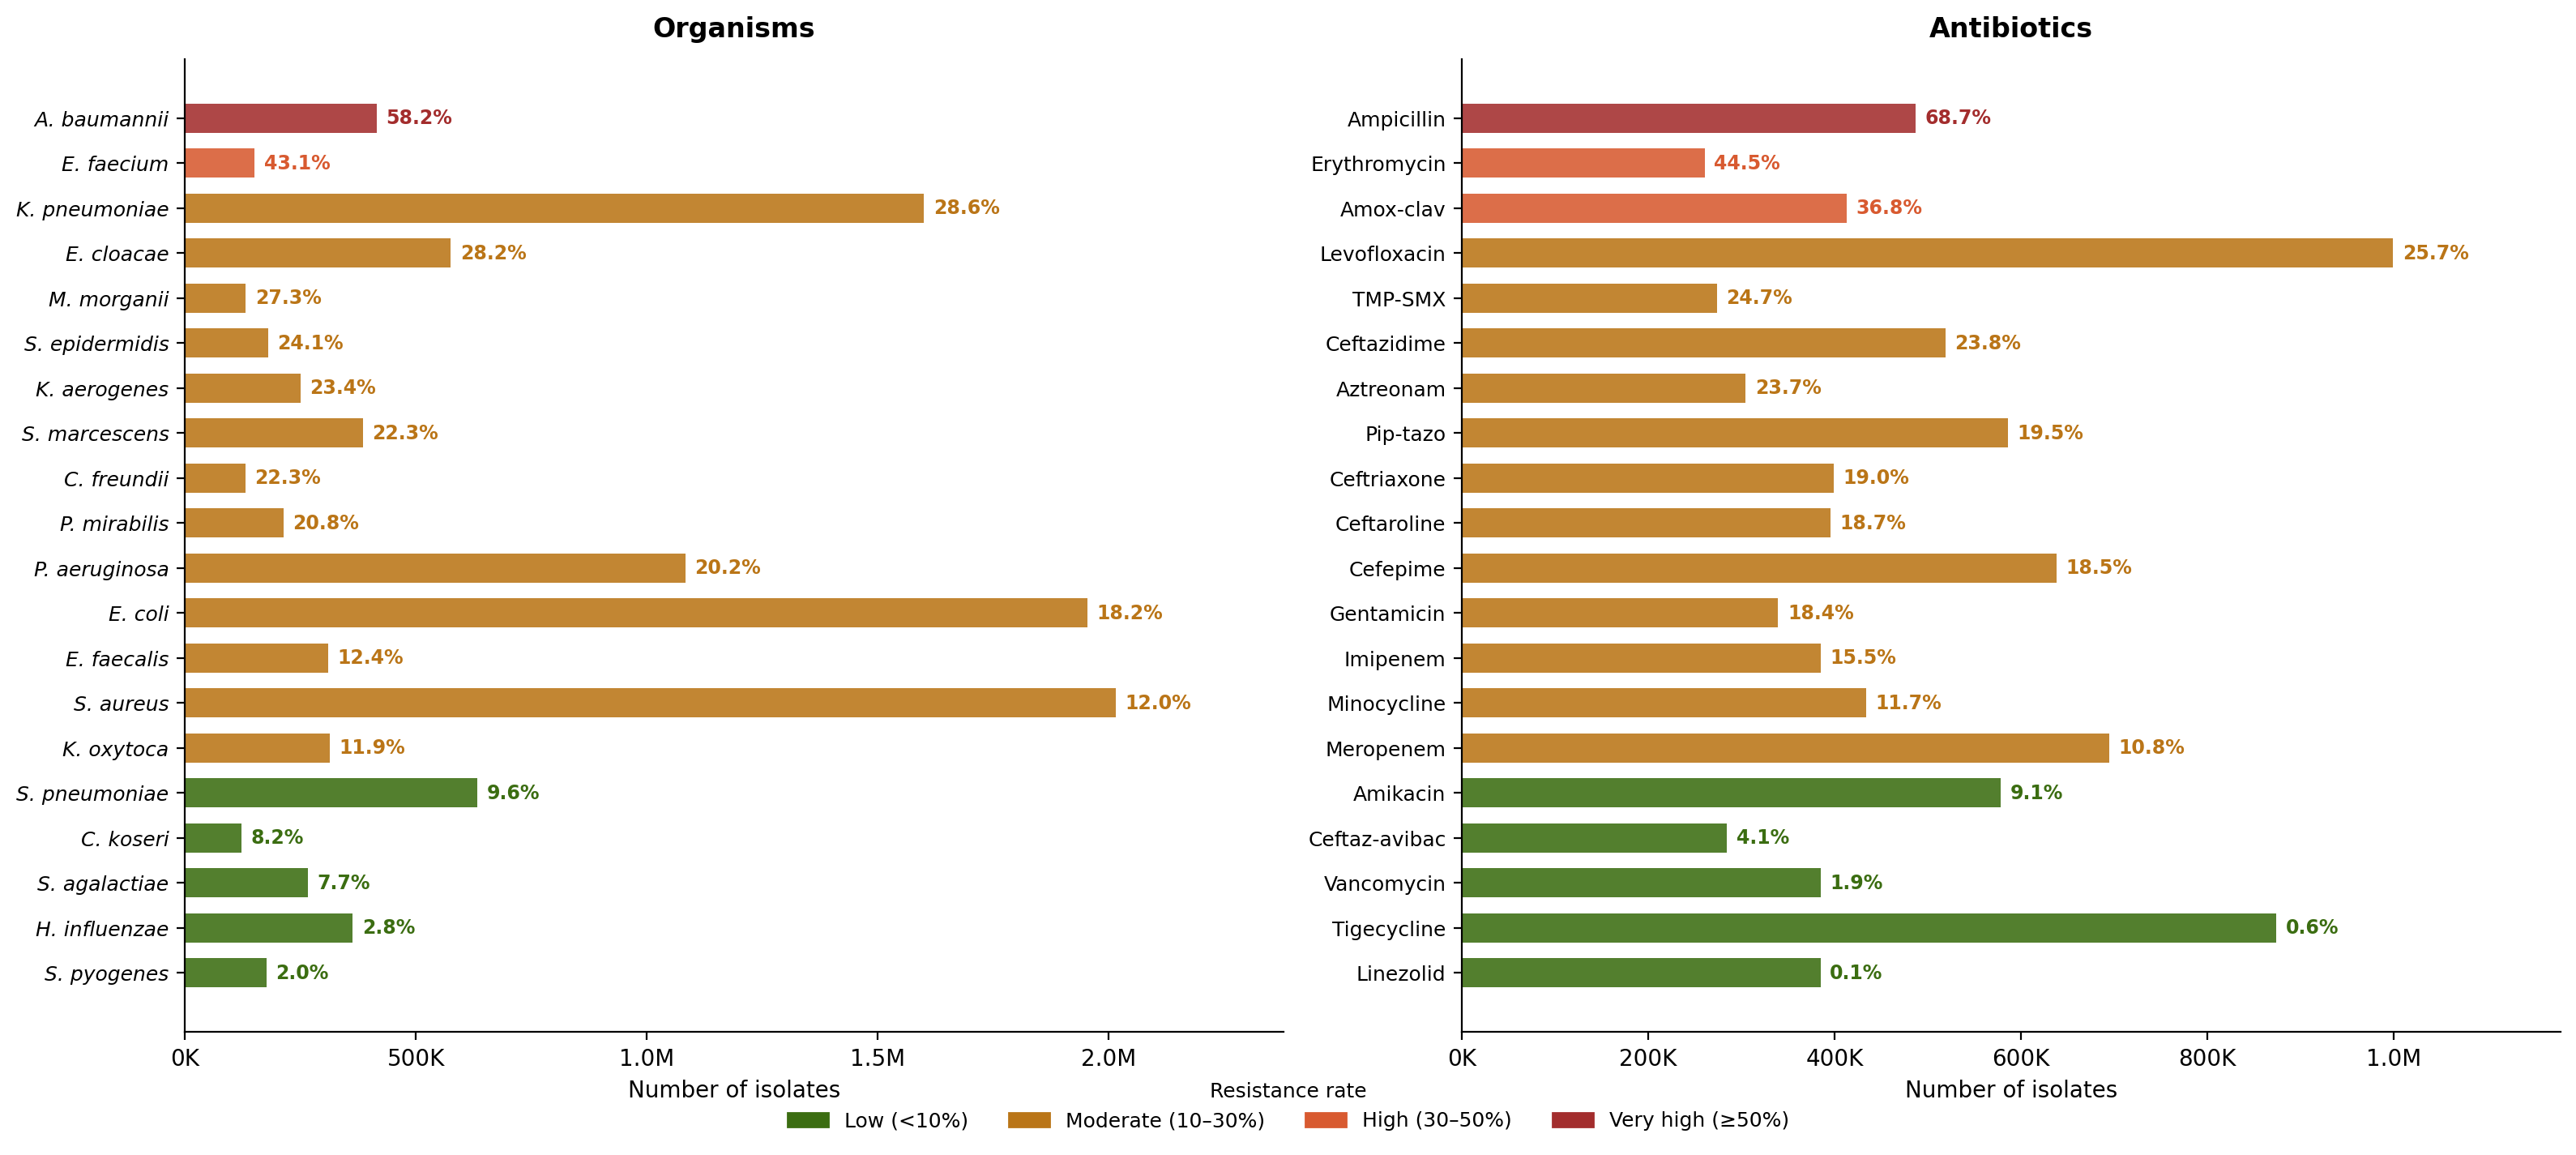

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Data---
org_data = [
    ('S. aureus',        2015474, 0.120160),
    ('E. coli',          1952790, 0.182499),
    ('K. pneumoniae',    1599804, 0.286052),
    ('P. aeruginosa',    1083600, 0.201525),
    ('S. pneumoniae',     633531, 0.095626),
    ('E. cloacae',        575799, 0.282324),
    ('A. baumannii',      415202, 0.581835),
    ('S. marcescens',     385649, 0.223364),
    ('H. influenzae',     363495, 0.028460),
    ('K. oxytoca',        312940, 0.118978),
    ('E. faecalis',       310523, 0.123563),
    ('S. agalactiae',     266243, 0.076994),
    ('K. aerogenes',      250182, 0.234205),
    ('P. mirabilis',      214041, 0.208222),
    ('S. epidermidis',    180661, 0.240904),
    ('S. pyogenes',       176363, 0.020237),
    ('E. faecium',        150851, 0.431306),
    ('M. morganii',       131768, 0.273405),
    ('C. freundii',       130975, 0.222523),
    ('C. koseri',         122940, 0.081568),
]

abx_data = [
    ('Levofloxacin',          999507, 0.257319),
    ('Tigecycline',           874308, 0.005616),
    ('Meropenem',             694576, 0.107910),
    ('Cefepime',              638415, 0.184974),
    ('Pip-tazo',              585982, 0.194854),
    ('Amikacin',              578379, 0.090562),
    ('Ceftazidime',           519024, 0.238290),
    ('Ampicillin',            487402, 0.687293),
    ('Minocycline',           434077, 0.116947),
    ('Amox-clav',             412841, 0.368050),
    ('Ceftriaxone',           399555, 0.190487),
    ('Ceftaroline',           395921, 0.187429),
    ('Imipenem',              385148, 0.154847),
    ('Linezolid',             385085, 0.001410),
    ('Vancomycin',            385004, 0.018571),
    ('Gentamicin',            339659, 0.184388),
    ('Aztreonam',             304618, 0.236972),
    ('Ceftaz-avibac',         284659, 0.040603),
    ('TMP-SMX',               274056, 0.246778),
    ('Erythromycin',          260815, 0.444825),
]

# Sort by R_rate ascending
org_data  = sorted(org_data,  key=lambda x: x[2])
abx_data  = sorted(abx_data,  key=lambda x: x[2])

def rcolor(r):
    if r < 0.10:  return '#3B6D11'
    elif r < 0.30: return '#BA7517'
    elif r < 0.50: return '#D85A30'
    else:          return '#A32D2D'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

for ax, data, title, italic in [
    (axes[0], org_data,  'Organisms',    True),
    (axes[1], abx_data,  'Antibiotics',  False),
]:
    names  = [d[0] for d in data]
    totals = [d[1] for d in data]
    rrates = [d[2] for d in data]
    colors = [rcolor(r) for r in rrates]
    y = np.arange(len(names))

    ax.barh(y, totals, color=colors, height=0.65, alpha=0.88)

    for i, (t, r) in enumerate(zip(totals, rrates)):
        ax.text(t + max(totals)*0.01, i, f'{r*100:.1f}%',
                va='center', ha='left', fontsize=8.5,
                color=rcolor(r), fontweight='bold')

    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=9,
                       style='italic' if italic else 'normal')
    ax.set_xlabel('Number of isolates', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1e3)}K'))
    ax.set_xlim(0, max(totals) * 1.18)

legend_patches = [
    mpatches.Patch(color='#3B6D11', label='Low (<10%)'),
    mpatches.Patch(color='#BA7517', label='Moderate (10–30%)'),
    mpatches.Patch(color='#D85A30', label='High (30–50%)'),
    mpatches.Patch(color='#A32D2D', label='Very high (≥50%)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02),
           title='Resistance rate', title_fontsize=9)

plt.tight_layout()
plt.savefig('fig1_sr_distribution.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig1_sr_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

## 3. Leakage Audit

Temporal split: Train ≤ 2020, Validation 2021–2022, Test > 2022.
Explicit audit confirms zero isolate ID overlap across all three partitions.


## 4. Global Macroeconomic Feature Engineering

World Bank indicators (GDP per capita, health expenditure % GDP, population density) and global antibiotic consumption (DDD/1000/day) are merged into the global dataset by country and year.

Missing values are imputed using forward fill then backward fill within each country group, with the global column mean applied as a fallback for countries with no data across any year.

Log transformations are applied to GDP per capita and antibiotic consumption to reduce right-skew.


In [6]:
# =============================================================================
# 4. Global Macroeconomic + Per-class Antibiotic Consumption
# =============================================================================

import os
import pandas as pd
import numpy as np

POP_DENSITY_PATH      = '/kaggle/input/datasets/uaisamangeldi/macrob/API_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv'
GDP_PCAP_PATH         = '/kaggle/input/datasets/uaisamangeldi/macrob/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv'
HEALTH_GDP_PATH       = '/kaggle/input/datasets/uaisamangeldi/macrob/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_938/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_938.csv'
CONSUMPTION_PATH      = '/kaggle/input/datasets/uaisamangeldi/consumption/antibiotic-consumption-rate.csv'
GLOBAL_DID_CLASS_PATH = '/kaggle/input/datasets/uaisamangeldi/globalddd/antibiotic_consumption_clean.csv'
full_df = pd.read_csv("/kaggle/working/combined_dataset.csv")
def wb_long_format(path, value_col_name):
    """Parse World Bank CSV (wide format) → long format keyed by country and year."""
    if not os.path.exists(path):
        print(f"  [MISSING] {path}")
        return pd.DataFrame()
    df = pd.read_csv(path, skiprows=4, low_memory=False)
    df.columns = df.columns.str.strip()
    if 'Country Name' not in df.columns:
        print(f"  [ERROR] 'Country Name' missing in {path}")
        return pd.DataFrame()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df_long = pd.melt(df, id_vars=['Country Name'], value_vars=year_cols,
                      var_name='year', value_name=value_col_name)
    df_long['year'] = df_long['year'].astype(int)
    df_long = df_long.rename(columns={'Country Name': 'country'})
    df_long[value_col_name] = pd.to_numeric(df_long[value_col_name], errors='coerce')
    result = df_long[['country', 'year', value_col_name]].dropna(subset=[value_col_name])
    print(f"  {value_col_name}: {len(result):,} rows, {result['country'].nunique()} countries")
    return result

# ── World Bank macros ─────────────────────────────────────────────────────────
print("Loading World Bank indicators...")
df_pop    = wb_long_format(POP_DENSITY_PATH, 'population_density_per_sq_km')
df_gdp    = wb_long_format(GDP_PCAP_PATH,    'gdp_per_capita_usd')
df_health = wb_long_format(HEALTH_GDP_PATH,  'health_expenditure_pct_gdp')

macro_df = df_gdp.copy()
for df_temp in [df_pop, df_health]:
    macro_df = macro_df.merge(df_temp, on=['country', 'year'], how='outer')

COUNTRY_MAP = {
    'United States': 'USA', 'United States of America': 'USA',
    'Russian Federation': 'Russia', 'Korea, Rep.': 'South Korea',
}
macro_df['country'] = macro_df['country'].replace(COUNTRY_MAP)
full_df['country']  = full_df['country'].replace(COUNTRY_MAP)

full_df = full_df[~full_df['antibiotic'].str.strip().isin(['Age', 'Date Collected', 'age', 'date collected'])]
print(f"After artifact removal: {len(full_df):,} rows")

drop_cols = [
    'gdp_per_capita_usd', 'population_density_per_sq_km', 'health_expenditure_pct_gdp',
    'consumption_ddd_per_1000_day', 'consumption_ddd_total', 'consumption_did_per_class',
    'log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class',
    'antibiotic_class',
]
full_df = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns])
full_df = full_df.merge(macro_df, on=['country', 'year'], how='left')

print("\nLoading total consumption...")
try:
    df_cons = pd.read_csv(CONSUMPTION_PATH)
    df_cons = df_cons.rename(columns={
        'Entity': 'country',
        'Year':   'year',
        'Defined daily doses of antibiotics and antituberculosis drugs used per 1,000 inhabitants per day': 'consumption_ddd_total'
    })
    df_cons = df_cons[['country', 'year', 'consumption_ddd_total']].copy()
    df_cons['country'] = df_cons['country'].replace({'Russian Federation': 'Russia', 'United States': 'USA'})
    full_df = full_df.merge(df_cons, on=['country', 'year'], how='left')
    print("  → OK")
except Exception as e:
    print(f"  → FAILED: {e}")
    full_df['consumption_ddd_total'] = np.nan

print("\nLoading per-class DDD...")
did_raw = pd.read_csv(GLOBAL_DID_CLASS_PATH)
DID_COUNTRY_MAP = {
    'Us': 'USA', 'Uk': 'United Kingdom', 'Uae': 'United Arab Emirates',
    'Korea': 'South Korea', 'Russian Federation': 'Russia',
}
did_raw['country'] = did_raw['country'].replace(DID_COUNTRY_MAP)
did_class = (did_raw[['country', 'year', 'antibiotic_class', 'consumption_DID']]
             .copy()
             .rename(columns={'consumption_DID': 'consumption_did_per_class'}))

ANTIBIOTIC_TO_CLASS_MAP = {
    # Carbapenems
    'Meropenem': 'Carbapenems', 'Imipenem': 'Carbapenems',
    'Doripenem': 'Carbapenems', 'Ertapenem': 'Carbapenems',
    # Fluoroquinolones
    'Ciprofloxacin': 'Fluoroquinolones', 'Levofloxacin': 'Fluoroquinolones',
    'Moxifloxacin': 'Fluoroquinolones',  'Ofloxacin': 'Fluoroquinolones',
    'Norfloxacin': 'Fluoroquinolones',
    # Cephalosporins
    'Ceftazidime': 'Cephalosporins',  'Cefepime': 'Cephalosporins',
    'Ceftriaxone': 'Cephalosporins',  'Cefixime': 'Cephalosporins',
    'Cefazolin': 'Cephalosporins',    'Cefotaxime': 'Cephalosporins',
    'Cefuroxime': 'Cephalosporins',   'Cefpodoxime': 'Cephalosporins',
    'Cefoxitin': 'Cephalosporins',    'Ceftolozane': 'Cephalosporins',
    'Ceftaroline': 'Cephalosporins',  'Ceftazidime avibactam': 'Cephalosporins',
    'Ceftolozane tazobactam': 'Cephalosporins', 'Cefiderocol': 'Cephalosporins',
    'Ceftazidime/ Avibactam': 'Cephalosporins', 'Ceftolozane/ Tazobactam': 'Cephalosporins',
    'Ceftibuten': 'Cephalosporins',
    # Aminoglycosides
    'Amikacin': 'Aminoglycosides',   'Gentamicin': 'Aminoglycosides',
    'Kanamycin': 'Aminoglycosides',  'Tobramycin': 'Aminoglycosides',
    'Netilmicin': 'Aminoglycosides',
    # Penicillins
    'Ampicillin': 'Penicillins',
    'Amoxicillin- clavulanic acid': 'Penicillins',
    'Amoxycillin clavulanate': 'Penicillins',
    'Amoxicillin-\nclavulanic acid': 'Penicillins',
    'Penicillin': 'Penicillins',
    'Piperacillin': 'Penicillins',
    'Piperacillin-tazobactam': 'Penicillins',
    'Piperacillin tazobactam': 'Penicillins',
    'Piperacillin-\ntazobactam': 'Penicillins',
    'Oxacillin': 'Penicillins',
    'Ampicillin sulbactam': 'Penicillins',
    'Ampicillin/ Sulbactam': 'Penicillins',
    # Macrolides
    'Azithromycin': 'Macrolides', 'Clarithromycin': 'Macrolides',
    'Erythromycin': 'Macrolides',
    # Glycopeptides
    'Vancomycin': 'Glycopeptides', 'Teicoplanin': 'Glycopeptides',
    # Tetracyclines
    'Doxycycline': 'Tetracyclines',  'Tetracycline': 'Tetracyclines',
    'Minocycline': 'Tetracyclines',  'Tigecycline': 'Tetracyclines',
    'Omadacycline': 'Tetracyclines',
    # Oxazolidinones
    'Linezolid': 'Oxazolidinones',
    # Polymyxins
    'Colistin': 'Polymyxins', 'Polymyxin B': 'Polymyxins',
    # Sulfonamides
    'Trimethoprim / sulfamethoxazole': 'Sulfonamides',
    'Trimethoprim-sulfamethoxazole':   'Sulfonamides',
    'Trimethoprim/ Sulfamethoxazole':  'Sulfonamides',
    'Trimethoprim sulfa':              'Sulfonamides',
    'Trimethoprim':                    'Sulfonamides',
    # Nitroimidazoles
    'Metronidazole': 'Nitroimidazoles',
    # Phosphonic acids
    'Fosfomycin': 'Phosphonic acids',
    # Amphenicols
    'Chloramphenicol': 'Amphenicols',
    # Monobactams
    'Aztreonam':             'Monobactams',
    'Aztreonam/ Avibactam':  'Monobactams',
    # Carbapenems + BLI
    'Meropenem vaborbactam':       'Carbapenems',
    'Meropenem/ Vaborbactam at 8': 'Carbapenems',
    'Imipenem/ Relebactam':        'Carbapenems',
    # Lincosamides
    'Clindamycin': 'Lincosamides',
    # Lipopeptides
    'Daptomycin': 'Lipopeptides',
    # Streptogramins
    'Quinupristin dalfopristin': 'Streptogramins',
}

full_df['antibiotic_class'] = full_df['antibiotic'].map(ANTIBIOTIC_TO_CLASS_MAP)

unmapped = full_df[full_df['antibiotic_class'].isna()]['antibiotic'].value_counts()
mapped_pct = full_df['antibiotic_class'].notna().mean() * 100
print(f"\n  antibiotic_class coverage: {mapped_pct:.1f}%")
if len(unmapped) > 0:
    print(f"  Unmapped antibiotics (add to map if frequent):")
    print(unmapped.head(15).to_string())
else:
    print("  All antibiotics successfully mapped!")

full_df = full_df.merge(did_class, on=['country', 'year', 'antibiotic_class'], how='left')

# ── Imputation: ffill/bfill within country, then global mean fallback ─────────
fill_cols = [
    'gdp_per_capita_usd', 'population_density_per_sq_km',
    'health_expenditure_pct_gdp', 'consumption_ddd_total',
    'consumption_did_per_class',
]
for col in fill_cols:
    if col in full_df.columns:
        full_df[col] = full_df.groupby('country')[col].transform(lambda x: x.ffill().bfill())
        full_df[col] = full_df[col].fillna(full_df[col].mean())

full_df['log_gdp_per_capita']            = np.log1p(full_df['gdp_per_capita_usd'].clip(lower=0))
full_df['log_consumption_ddd']           = np.log1p(full_df['consumption_ddd_total'].clip(lower=0))
full_df['log_consumption_did_per_class'] = np.log1p(full_df['consumption_did_per_class'].clip(lower=0))

# Drop raw versions
full_df = full_df.drop(columns=['gdp_per_capita_usd', 'consumption_ddd_total', 'consumption_did_per_class'])

# ── Save
import os
os.makedirs('/kaggle/working', exist_ok=True)
full_df.to_csv('/kaggle/working/full_amr_with_macro.csv', index=False)

log_feature_cols = ['log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class']
print(f"\n Saved full_amr_with_macro.csv | Shape: {full_df.shape}")
print("\nCoverage (non-null %):")
print((full_df[['health_expenditure_pct_gdp', 'population_density_per_sq_km'] + log_feature_cols]
       .notna().mean() * 100).round(1))

Loading World Bank indicators...
  population_density_per_sq_km: 6,217 rows, 264 countries
  gdp_per_capita_usd: 6,433 rows, 262 countries
  health_expenditure_pct_gdp: 5,716 rows, 241 countries
After artifact removal: 12,316,484 rows

Loading total consumption...
  → OK

Loading per-class DDD...

  antibiotic_class coverage: 100.0%
  All antibiotics successfully mapped!

✅ Saved full_amr_with_macro.csv | Shape: (12316484, 15)

Coverage (non-null %):
health_expenditure_pct_gdp       100.0
population_density_per_sq_km     100.0
log_gdp_per_capita               100.0
log_consumption_ddd              100.0
log_consumption_did_per_class    100.0
dtype: float64


In [3]:
full_df = pd.read_csv('/kaggle/input/datasets/user/full-df/full_amr_with_macro.csv', low_memory=False)
full_df_sorted = full_df.sort_values('year').reset_index(drop=True)

TRAIN_CUTOFF, VAL_CUTOFF = 2018, 2020

train = full_df_sorted[full_df_sorted['year'] <= TRAIN_CUTOFF]
val   = full_df_sorted[(full_df_sorted['year'] > TRAIN_CUTOFF) & (full_df_sorted['year'] <= VAL_CUTOFF)]
test  = full_df_sorted[full_df_sorted['year'] > VAL_CUTOFF]

print(f"Train : {len(train):,} rows (≤ {TRAIN_CUTOFF})")
print(f"Val   : {len(val):,} rows ({TRAIN_CUTOFF+1}–{VAL_CUTOFF})")
print(f"Test  : {len(test):,} rows (> {VAL_CUTOFF})")

train_ids, val_ids, test_ids = set(train['isolate_id']), set(val['isolate_id']), set(test['isolate_id'])
print(f"\nTrain-Val overlap  : {len(train_ids & val_ids):,}")
print(f"Train-Test overlap : {len(train_ids & test_ids):,}")
print(f"Val-Test overlap   : {len(val_ids & test_ids):,}")
print("\nLeakage audit PASSED." if len(train_ids & test_ids) == 0 else "\nWARNING: Leakage detected.")

Train : 7,844,260 rows (≤ 2018)
Val   : 1,798,142 rows (2019–2020)
Test  : 2,674,082 rows (> 2020)

Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0

Leakage audit PASSED.


In [ ]:
!pip install plotly geopandas kaleido pycountry

In [28]:
!pip install -U kaleido

Countries with sufficient data : 81
R_rate range : 0.074 – 0.663


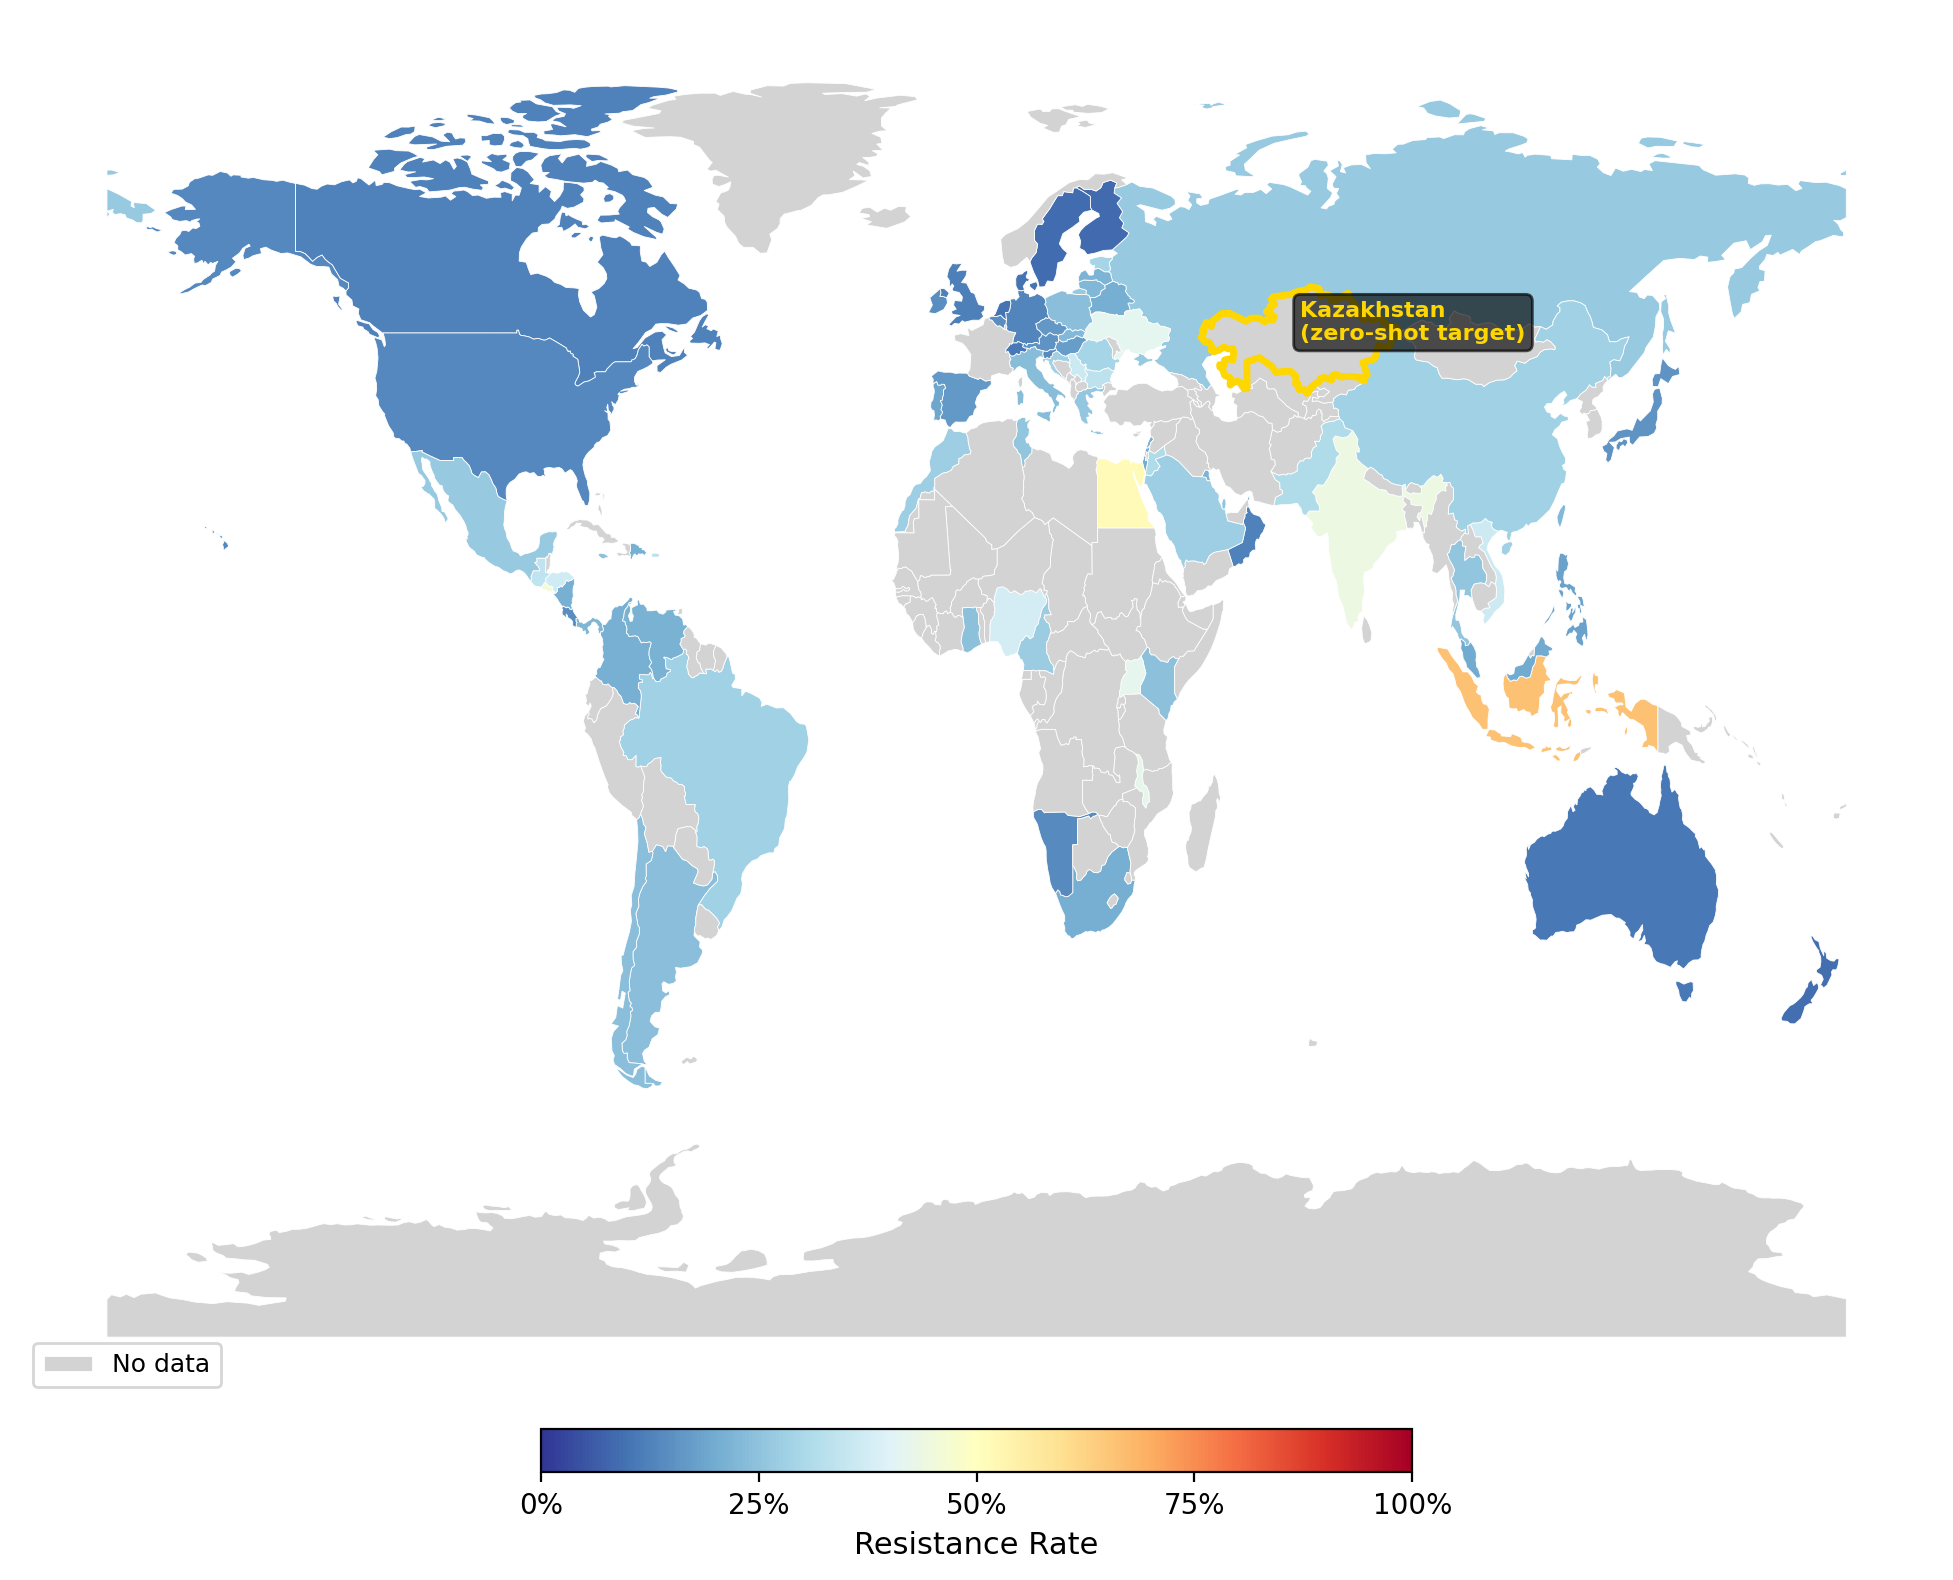

Saved: fig1_world_rrate_map.png


In [31]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import pycountry
import warnings
import requests
import zipfile
import io

warnings.filterwarnings('ignore')

# ── Load data
full_df = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)

# ── Compute R_rate per country
country_stats = (
    full_df.groupby('country')
    .agg(
        n_isolates = ('isolate_id', 'nunique'),
        n_tested   = ('resistance', 'count'),
        n_resistant= ('resistance', 'sum'),
    )
    .reset_index()
)

country_stats['R_rate'] = country_stats['n_resistant'] / country_stats['n_tested']
country_stats = country_stats[country_stats['n_tested'] >= 100].copy()

# ── Country name → ISO-3
MANUAL_MAP = {
    'USA': 'USA', 'Russia': 'RUS', 'South Korea': 'KOR',
    'Iran': 'IRN', 'Taiwan': 'TWN', 'Bolivia': 'BOL',
    'Venezuela': 'VEN', 'Vietnam': 'VNM', 'Tanzania': 'TZA',
    'Czech Republic': 'CZE', 'Slovakia': 'SVK', 'Moldova': 'MDA',
    'Syria': 'SYR', 'Laos': 'LAO',
}

def name_to_iso3(name):
    if name in MANUAL_MAP:
        return MANUAL_MAP[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

country_stats['iso3'] = country_stats['country'].apply(name_to_iso3)
country_stats = country_stats.dropna(subset=['iso3'])

print(f"Countries with sufficient data : {len(country_stats)}")
print(f"R_rate range : {country_stats['R_rate'].min():.3f} – {country_stats['R_rate'].max():.3f}")

# ── Download Natural Earth low-res world map
def get_naturalearth_lowres():
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    print("Downloading Natural Earth world boundaries...")
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall("/kaggle/working/ne_110m_admin_0_countries")
    return gpd.read_file("/kaggle/working/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

world = get_naturalearth_lowres()

# ── Merge with statistics
world = world.merge(
    country_stats[['iso3', 'R_rate']],
    left_on='ISO_A3',
    right_on='iso3',
    how='left'
)

# ── Figure 1a: World Choropleth
fig, ax = plt.subplots(figsize=(16, 8))

world.plot(
    column='R_rate', 
    ax=ax,
    cmap='RdYlBu_r', 
    vmin=0, 
    vmax=1,
    edgecolor='white', 
    linewidth=0.3,
    missing_kwds={'color': '#d3d3d3'},
    legend=False,
)

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.03, pad=0.02, shrink=0.45)
cbar.set_label('Resistance Rate', fontsize=11)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])

#Kazakhstan
kz_geom = world[world['ISO_A3'] == 'KAZ']
if len(kz_geom):
    kz_geom.plot(ax=ax, facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=5)
    ax.annotate(
        'Kazakhstan\n(zero-shot target)',
        xy=(67, 48), fontsize=8, color='#FFD700', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.65), zorder=6,
    )

ax.legend(handles=[Patch(facecolor='#d3d3d3', edgecolor='white', label='No data')],
          loc='lower left', fontsize=9, frameon=True)

ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_world_rrate_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig1_world_rrate_map.png")

In [28]:
# Table 2 : Country
table2 = country_stats[['country', 'iso3', 'n_tested', 'n_resistant', 
                       'R_rate', 'who_region']].sort_values('R_rate', ascending=False)

table2 = table2.rename(columns={
    'n_tested': 'N Tested',
    'n_resistant': 'N Resistant',
    'R_rate': 'Resistance Rate',
    'who_region': 'WHO Region'
})

table2.to_csv('/kaggle/working/table2_country_rrate.csv', index=False)

print("\n=== TABLE 2: Top 10 countries by Resistance Rate ===")
display(table2.head(10).style.format({
    'Resistance Rate': '{:.1%}'
}).background_gradient(cmap='Reds', subset=['Resistance Rate']))


=== TABLE 2: Top 10 countries by Resistance Rate ===


,country,iso3,N Tested,N Resistant,Resistance Rate,WHO Region
30,Indonesia,IDN,700,464,66.3%,SEARO
17,Egypt,EGY,2642,1363,51.6%,EMRO
18,El Salvador,SLV,2647,1221,46.1%,AMR
29,India,IND,205815,90788,44.1%,SEARO
44,Malawi,MWI,3437,1452,42.2%,AFRO
80,Uganda,UGA,4054,1710,42.2%,AFRO
81,Ukraine,UKR,35440,14748,41.6%,EUR
53,Nigeria,NGA,62731,23603,37.6%,AFRO
26,Honduras,HND,3320,1231,37.1%,AMR
84,Vietnam,VNM,1475,538,36.5%,WPRO


## 5. Feature Set Definition

Country name is deliberately excluded to enable zero-shot generalization.
The model characterizes each country purely through its macroeconomic profile.

Feature set matches the final validated pipeline from the original notebook.


In [5]:
CAT_FEATURES = ['organism', 'antibiotic', 'antibiotic_class']

NUM_FEATURES = [
    'year',
    'log_gdp_per_capita',
    'health_expenditure_pct_gdp',
    'population_density_per_sq_km',
    'log_consumption_ddd',
    'log_consumption_did_per_class',
]

FEATURES = CAT_FEATURES + NUM_FEATURES

print("Categorical features :", CAT_FEATURES)
print("Numerical features   :", NUM_FEATURES)
print("Total features       :", len(FEATURES))

Categorical features : ['organism', 'antibiotic', 'antibiotic_class']
Numerical features   : ['year', 'log_gdp_per_capita', 'health_expenditure_pct_gdp', 'population_density_per_sq_km', 'log_consumption_ddd', 'log_consumption_did_per_class']
Total features       : 9

Note: 'country' excluded — zero-shot design requires country-agnostic features.
Note: 'data_source' excluded — would leak database identity into predictions.


In [6]:
# ── Diagnostic: post-Soviet countries in the dataset
POST_SOVIET = [
    'Kazakhstan', 'Russia', 'Ukraine', 'Belarus', 'Uzbekistan',
    'Azerbaijan', 'Georgia', 'Armenia', 'Moldova', 'Kyrgyzstan',
    'Tajikistan', 'Turkmenistan', 'Estonia', 'Latvia', 'Lithuania'
]

ps_check = (full_df[full_df['country'].isin(POST_SOVIET)]
            .groupby('country')
            .agg(n_rows=('resistance', 'count'),
                 n_isolates=('isolate_id', 'nunique'),
                 years=('year', lambda x: f"{x.min()}–{x.max()}"))
            .reset_index()
            .sort_values('n_rows', ascending=False))

print("Post-Soviet countries in full_df:")
print(ps_check.to_string(index=False))
print(f"\nKazakhstan present: {'Kazakhstan' in full_df['country'].values}")

Post-Soviet countries in full_df:
  country  n_rows  n_isolates     years
   Russia  192630       16191 2012–2019
Lithuania   50108        4137 2006–2023
   Latvia   35775        3187 2004–2022
  Ukraine   35440        2664 2014–2023
  Belarus    5546         424 2016–2018
  Estonia     124          14 2009–2011

Kazakhstan present: False


## 6. Domain Split

Kazakhstan is excluded from the source (training) domain entirely.
Proxy countries are used for LOCO validation as surrogates for Kazakhstan.


## 7. Model Training

Three models trained on identical feature sets and temporal splits:
- **Random Forest** — baseline (class_weight='balanced')
- **XGBoost** — GPU-accelerated, histogram method (scale_pos_weight)
- **LightGBM** — GPU-accelerated, leaf-wise growth (scale_pos_weight, early stopping)
- **MLP**
- **CatBoost**
- **Logistic Regression**
Temporal split: Train ≤ 2020 | Validation 2021–2022.
Label encoding fit on training data only — validation labels mapped, unknowns assigned -1.


In [10]:
!pip install catboost

# Main Training Session

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SklearnScaler
from sklearn.metrics import f1_score, recall_score, precision_score
from scipy import stats
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.ensemble import RandomForestClassifier

# ====================== DeLong Test Function ======================
def delong_test(auc1, auc2, n_pos, n_neg):
    """Simple DeLong test (Hanley-McNeil approximation)"""
    q1 = auc1 * (1 - auc1)
    q2 = auc1**2 / (1 - auc1) if auc1 < 1 else 0
    var = (q1 + (n_pos-1)*(auc1/(2-auc1) - auc1**2) + (n_neg-1)*(2*auc1**2/(1+auc1) - auc1**2)) / (n_pos * n_neg)
    z = (auc1 - auc2) / np.sqrt(var * 2)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

# ====================== TEMPORAL SPLIT ======================
source_sorted = source_df.sort_values('year').reset_index(drop=True)
train_df = source_sorted[source_sorted['year'] <= 2020].copy()
val_df = source_sorted[(source_sorted['year'] > 2020) & (source_sorted['year'] <= 2022)].copy()
print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Label encoding (fit on train only) ───────────────────────────────────────
label_encoders = {}
X_train = train_df[FEATURES].copy()
X_val = val_df[FEATURES].copy()
y_train = train_df['resistance'].values
y_val = val_df['resistance'].values

for col in CAT_FEATURES:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_val[col] = X_val[col].fillna('unknown').astype(str).map(lambda s, d=le_dict: d.get(s, -1))
    label_encoders[col] = le

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
results = {}
n_pos = y_val.sum()
n_neg = len(y_val) - n_pos

# ── 1. Logistic Regression ───────────────────────────────────────────────────
print("\nTraining Logistic Regression...")
scaler_lr = SklearnScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)
lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000,
    solver='saga', random_state=42, n_jobs=-1
)
lr_model.fit(X_train_lr, y_train)
y_pred_lr = lr_model.predict_proba(X_val_lr)[:, 1]
y_pred_lr_bin = (y_pred_lr > 0.5).astype(int)

results['Logistic Regression'] = {
    'auc': roc_auc_score(y_val, y_pred_lr),
    'auprc': average_precision_score(y_val, y_pred_lr),
    'precision': precision_score(y_val, y_pred_lr_bin),
    'recall': recall_score(y_val, y_pred_lr_bin),
    'f1': f1_score(y_val, y_pred_lr_bin),
}
print(f"Logistic Regression — AUC: {results['Logistic Regression']['auc']:.4f} | AUPRC: {results['Logistic Regression']['auprc']:.4f} | F1: {results['Logistic Regression']['f1']:.4f}")

# ── 2. Random Forest ─────────────────────────────────────────────────────────
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict_proba(X_val)[:, 1]
y_pred_rf_bin = (y_pred_rf > 0.5).astype(int)

results['Random Forest'] = {
    'auc': roc_auc_score(y_val, y_pred_rf),
    'auprc': average_precision_score(y_val, y_pred_rf),
    'precision': precision_score(y_val, y_pred_rf_bin),
    'recall': recall_score(y_val, y_pred_rf_bin),
    'f1': f1_score(y_val, y_pred_rf_bin),
}
print(f"Random Forest — AUC: {results['Random Forest']['auc']:.4f} | AUPRC: {results['Random Forest']['auprc']:.4f} | F1: {results['Random Forest']['f1']:.4f}")

# ── 3. XGBoost ───────────────────────────────────────────────────────────────
print("\nTraining XGBoost...")
xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': ['auc', 'aucpr'],
    'max_depth': 7, 'learning_rate': 0.03,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_weight': 5, 'scale_pos_weight': pos_weight,
    'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1,
}
try:
    import cupy
    xgb_params['device'] = 'cuda'
    print("XGBoost → GPU")
except ImportError:
    xgb_params['device'] = 'cpu'
    print("XGBoost → CPU")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=FEATURES)

model_xgb = xgb.train(
    xgb_params, dtrain,
    num_boost_round=3000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=200
)
y_pred_xgb = model_xgb.predict(dval)
y_pred_xgb_bin = (y_pred_xgb > 0.5).astype(int)

results['XGBoost'] = {
    'auc': roc_auc_score(y_val, y_pred_xgb),
    'auprc': average_precision_score(y_val, y_pred_xgb),
    'precision': precision_score(y_val, y_pred_xgb_bin),
    'recall': recall_score(y_val, y_pred_xgb_bin),
    'f1': f1_score(y_val, y_pred_xgb_bin),
}
print(f"XGBoost — AUC: {results['XGBoost']['auc']:.4f} | AUPRC: {results['XGBoost']['auprc']:.4f} | F1: {results['XGBoost']['f1']:.4f} | Best round: {model_xgb.best_iteration}")

# ── 4. LightGBM ──────────────────────────────────────────────────────────────
print("\nTraining LightGBM...")
lgb_params = {
    'objective': 'binary', 'metric': ['auc', 'aucpr'],
    'learning_rate': 0.03, 'max_depth': 7, 'num_leaves': 63,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_samples': 50, 'scale_pos_weight': pos_weight,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1,
}
try:
    import pyopencl
    lgb_params['device'] = 'gpu'
    print("LightGBM → GPU")
except ImportError:
    lgb_params['device'] = 'cpu'
    print("LightGBM → CPU")

train_lgb = lgb.Dataset(X_train, label=y_train)
val_lgb = lgb.Dataset(X_val, label=y_val, reference=train_lgb)

model_lgb = lgb.train(
    lgb_params, train_lgb,
    num_boost_round=5000,
    valid_sets=[train_lgb, val_lgb], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)
y_pred_lgb = model_lgb.predict(X_val)
y_pred_lgb_bin = (y_pred_lgb > 0.5).astype(int)

results['LightGBM'] = {
    'auc': roc_auc_score(y_val, y_pred_lgb),
    'auprc': average_precision_score(y_val, y_pred_lgb),
    'precision': precision_score(y_val, y_pred_lgb_bin),
    'recall': recall_score(y_val, y_pred_lgb_bin),
    'f1': f1_score(y_val, y_pred_lgb_bin),
}
print(f"LightGBM — AUC: {results['LightGBM']['auc']:.4f} | AUPRC: {results['LightGBM']['auprc']:.4f} | F1: {results['LightGBM']['f1']:.4f} | Best round: {model_lgb.best_iteration}")

# ── 5. CatBoost ──────────────────────────────────────────────────────────────
print("\nTraining CatBoost...")
X_train_cb = train_df[FEATURES].copy()
X_val_cb = val_df[FEATURES].copy()
for col in CAT_FEATURES:
    X_train_cb[col] = X_train_cb[col].fillna('unknown').astype(str)
    X_val_cb[col] = X_val_cb[col].fillna('unknown').astype(str)

cb_model = CatBoostClassifier(
    iterations=3000, learning_rate=0.03,
    depth=7, l2_leaf_reg=3,
    scale_pos_weight=pos_weight,
    cat_features=CAT_FEATURES,
    eval_metric='AUC',
    early_stopping_rounds=100,
    random_seed=42, verbose=200,
    task_type='GPU' if torch.cuda.is_available() else 'CPU',
)
cb_model.fit(X_train_cb, y_train, eval_set=(X_val_cb, y_val), use_best_model=True)
y_pred_cb = cb_model.predict_proba(X_val_cb)[:, 1]
y_pred_cb_bin = (y_pred_cb > 0.5).astype(int)

results['CatBoost'] = {
    'auc': roc_auc_score(y_val, y_pred_cb),
    'auprc': average_precision_score(y_val, y_pred_cb),
    'precision': precision_score(y_val, y_pred_cb_bin),
    'recall': recall_score(y_val, y_pred_cb_bin),
    'f1': f1_score(y_val, y_pred_cb_bin),
}
print(f"CatBoost — AUC: {results['CatBoost']['auc']:.4f} | AUPRC: {results['CatBoost']['auprc']:.4f} | F1: {results['CatBoost']['f1']:.4f}")

# ── 6. MLP ───────────────────────────────────────────────────────────────────
print("\nTraining MLP...")
scaler_mlp = SklearnScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train.values.astype(np.float32))
X_val_mlp = scaler_mlp.transform(X_val.values.astype(np.float32))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"MLP → {device}")

train_tensor = TensorDataset(torch.tensor(X_train_mlp), torch.tensor(y_train, dtype=torch.float32))
val_tensor = TensorDataset(torch.tensor(X_val_mlp), torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_tensor, batch_size=4096, shuffle=True)
val_loader = DataLoader(val_tensor, batch_size=4096, shuffle=False)

class AMR_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp = AMR_MLP(X_train_mlp.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_auc = 0.0
best_weights = None
patience_counter = 0
PATIENCE = 10

for epoch in range(100):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        optimizer.step()
    
    mlp.eval()
    val_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            val_preds.append(mlp(xb.to(device)).cpu().numpy())
    val_preds = np.concatenate(val_preds)
    
    val_auc = roc_auc_score(y_val, val_preds)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_weights = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

mlp.load_state_dict(best_weights)
mlp.eval()

y_pred_mlp = np.concatenate([
    mlp(torch.tensor(xb, dtype=torch.float32).to(device)).cpu().detach().numpy()
    for xb, _ in val_loader
])

y_pred_mlp_bin = (y_pred_mlp > 0.5).astype(int)

results['MLP'] = {
    'auc': roc_auc_score(y_val, y_pred_mlp),
    'auprc': average_precision_score(y_val, y_pred_mlp),
    'precision': precision_score(y_val, y_pred_mlp_bin),
    'recall': recall_score(y_val, y_pred_mlp_bin),
    'f1': f1_score(y_val, y_pred_mlp_bin),
}
print(f"MLP — AUC: {results['MLP']['auc']:.4f} | AUPRC: {results['MLP']['auprc']:.4f} | F1: {results['MLP']['f1']:.4f} | Recall: {results['MLP']['recall']:.4f}")

# ── Summary Table ────────────────────────────────────────────────────────────
print("\n" + "="*90)
print(f"{'Model':<22} {'AUC':>8} {'AUPRC':>8} {'Precision':>9} {'Recall':>8} {'F1':>8}")
print("="*90)
for model_name, metrics in results.items():
    print(f"{model_name:<22} {metrics['auc']:>8.4f} {metrics['auprc']:>8.4f} "
          f"{metrics['precision']:>9.4f} {metrics['recall']:>8.4f} {metrics['f1']:>8.4f}")
print("="*90)

# ── DeLong Tests (vs LightGBM) ───────────────────────────────────────────────
print("\nDeLong Test (p-value vs LightGBM):")
lgb_auc = results['LightGBM']['auc']
for name, metrics in results.items():
    if name == 'LightGBM': continue
    z, p = delong_test(lgb_auc, metrics['auc'], n_pos, n_neg)
    print(f"{name:20} vs LightGBM → p = {p:.4f} {'(significant)' if p < 0.05 else ''}")

# ── Save models ──────────────────────────────────────────────────────────────
model_xgb.save_model('/kaggle/working/xgboost_model.json')
model_lgb.save_model('/kaggle/working/lightgbm_model.txt')
cb_model.save_model('/kaggle/working/catboost_model.cbm')
torch.save(best_weights, '/kaggle/working/mlp_weights.pt')

with open('/kaggle/working/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
with open('/kaggle/working/scaler_mlp.pkl', 'wb') as f:
    pickle.dump(scaler_mlp, f)

print("\nAll models saved successfully.")

Train: 9,642,402 | Val: 1,879,168

Training Logistic Regression...
Logistic Regression — AUC: 0.6270 | AUPRC: 0.2975 | F1: 0.3677

Training Random Forest...
Random Forest — AUC: 0.8612 | AUPRC: 0.6602 | F1: 0.5773

Training XGBoost...
XGBoost → GPU
[0]	train-auc:0.82119	train-aucpr:0.57187	val-auc:0.78510	val-aucpr:0.53749
[200]	train-auc:0.89316	train-aucpr:0.68651	val-auc:0.85114	val-aucpr:0.63754
[400]	train-auc:0.90267	train-aucpr:0.70918	val-auc:0.85659	val-aucpr:0.65763
[600]	train-auc:0.90648	train-aucpr:0.71973	val-auc:0.85811	val-aucpr:0.66687
[800]	train-auc:0.90912	train-aucpr:0.72721	val-auc:0.85993	val-aucpr:0.67433
[1000]	train-auc:0.91075	train-aucpr:0.73167	val-auc:0.86128	val-aucpr:0.67863
[1200]	train-auc:0.91199	train-aucpr:0.73476	val-auc:0.86213	val-aucpr:0.68127
[1400]	train-auc:0.91300	train-aucpr:0.73740	val-auc:0.86297	val-aucpr:0.68365
[1600]	train-auc:0.91381	train-aucpr:0.73953	val-auc:0.86377	val-aucpr:0.68536
[1800]	train-auc:0.91446	train-aucpr:0.74115	va

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8280095	best: 0.8280095 (0)	total: 1.06s	remaining: 53m 2s
200:	test: 0.8706873	best: 0.8706873 (200)	total: 2m 58s	remaining: 41m 25s
400:	test: 0.8746271	best: 0.8746271 (400)	total: 5m 42s	remaining: 36m 59s
600:	test: 0.8764888	best: 0.8764888 (600)	total: 8m 24s	remaining: 33m 31s
800:	test: 0.8775193	best: 0.8775193 (800)	total: 11m 1s	remaining: 30m 15s
1000:	test: 0.8786003	best: 0.8786003 (1000)	total: 13m 38s	remaining: 27m 13s
1200:	test: 0.8790288	best: 0.8790288 (1200)	total: 16m 19s	remaining: 24m 27s
1400:	test: 0.8796510	best: 0.8796510 (1400)	total: 18m 56s	remaining: 21m 36s
1600:	test: 0.8801171	best: 0.8801171 (1600)	total: 21m 34s	remaining: 18m 51s
1800:	test: 0.8805993	best: 0.8806111 (1793)	total: 24m 19s	remaining: 16m 11s
2000:	test: 0.8810347	best: 0.8810347 (2000)	total: 27m	remaining: 13m 28s
bestTest = 0.8812051713
bestIteration = 2096
Shrink model to first 2097 iterations.
CatBoost — AUC: 0.8812 | AUPRC: 0.6997 | F1: 0.5936

Training MLP...
MLP

In [33]:
import zipfile
import os

exclude_files = {'combined_dataset.csv'}
working_dir = '/kaggle/working'

with zipfile.ZipFile('/kaggle/working/models_and_results.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(working_dir):
        if fname in exclude_files or fname == 'models_and_results.zip':
            continue
        fpath = os.path.join(working_dir, fname)
        if os.path.isfile(fpath):
            zf.write(fpath, fname)
            print(f"  Added: {fname}")

print("\nDone. Download: /kaggle/working/models_and_results.zip")

  Added: kz_top_resistance_risks.csv
  Added: loco_final_results.csv
  Added: mlp_weights.pt
  Added: kz_ground_truth.csv
  Added: full_amr_with_macro.csv
  Added: catboost_model.cbm
  Added: scaler_mlp.pkl
  Added: xgboost_model.json
  Added: kazakhstan_final_prediction_input_2017_2023.csv
  Added: lightgbm_model.txt
  Added: kz_top_resistance_risks_matched.csv
  Added: lgb_calibration_plot.png
  Added: kz_zero_shot_predictions.csv
  Added: loco_predictions.csv
  Added: label_encoders.pkl

Done. Download: /kaggle/working/models_and_results.zip


SCALE_POS_WEIGHT: 4.3553

--- Step 1: Retrain with temporal split ---
ES train : 7,670,980 | ES val : 1,754,481 | Test : 2,657,407


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8370621	best: 0.8370621 (0)	total: 810ms	remaining: 1h 7m 27s
200:	test: 0.8774545	best: 0.8774545 (200)	total: 2m 19s	remaining: 55m 23s
400:	test: 0.8811346	best: 0.8811346 (400)	total: 4m 17s	remaining: 49m 9s
600:	test: 0.8828894	best: 0.8828894 (600)	total: 6m 22s	remaining: 46m 39s
800:	test: 0.8839642	best: 0.8839642 (800)	total: 8m 26s	remaining: 44m 17s
1000:	test: 0.8847274	best: 0.8847274 (1000)	total: 10m 30s	remaining: 41m 57s
1200:	test: 0.8852690	best: 0.8852704 (1199)	total: 12m 37s	remaining: 39m 56s
1400:	test: 0.8858262	best: 0.8858262 (1400)	total: 14m 43s	remaining: 37m 48s
1600:	test: 0.8861592	best: 0.8861628 (1598)	total: 16m 50s	remaining: 35m 44s
1800:	test: 0.8866099	best: 0.8866099 (1800)	total: 18m 57s	remaining: 33m 40s
2000:	test: 0.8870069	best: 0.8870088 (1999)	total: 21m 11s	remaining: 31m 46s
2200:	test: 0.8873355	best: 0.8873553 (2164)	total: 23m 16s	remaining: 29m 36s
bestTest = 0.8874276876
bestIteration = 2274
Shrink model to first 2275

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 690ms	remaining: 26m 7s
100:	total: 1m 28s	remaining: 31m 52s
200:	total: 2m 46s	remaining: 28m 39s
300:	total: 4m	remaining: 26m 17s
400:	total: 5m 11s	remaining: 24m 14s
500:	total: 6m 25s	remaining: 22m 44s
600:	total: 7m 38s	remaining: 21m 16s
700:	total: 8m 49s	remaining: 19m 47s
800:	total: 10m 1s	remaining: 18m 25s
900:	total: 11m 14s	remaining: 17m 7s
1000:	total: 12m 27s	remaining: 15m 50s
1100:	total: 13m 39s	remaining: 14m 32s
1200:	total: 14m 52s	remaining: 13m 17s
1300:	total: 16m 7s	remaining: 12m 3s
1400:	total: 17m 19s	remaining: 10m 47s
1500:	total: 18m 32s	remaining: 9m 33s
1600:	total: 19m 44s	remaining: 8m 18s
1700:	total: 21m	remaining: 7m 4s
1800:	total: 22m 12s	remaining: 5m 49s
1900:	total: 23m 25s	remaining: 4m 35s
2000:	total: 24m 40s	remaining: 3m 21s
2100:	total: 25m 53s	remaining: 2m 7s
2200:	total: 27m 8s	remaining: 54s
2273:	total: 28m 3s	remaining: 0us
✅ Retrained model saved

Test AUC  : 0.8802
Test AUPRC: 0.6940

--- Step 2: Feature Importanc

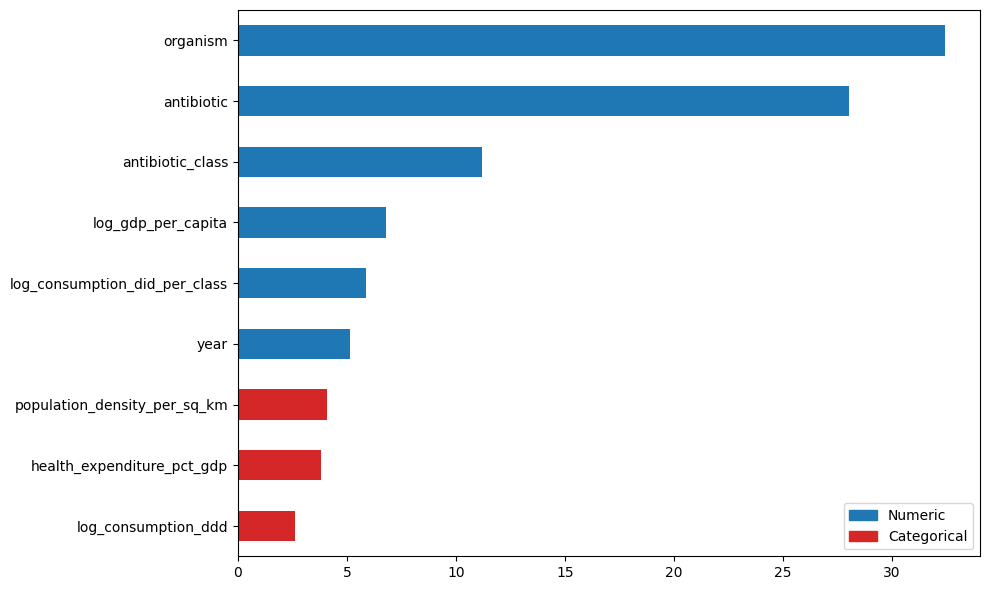

✅ Saved feature_importance.png

--- Step 3: SHAP ---


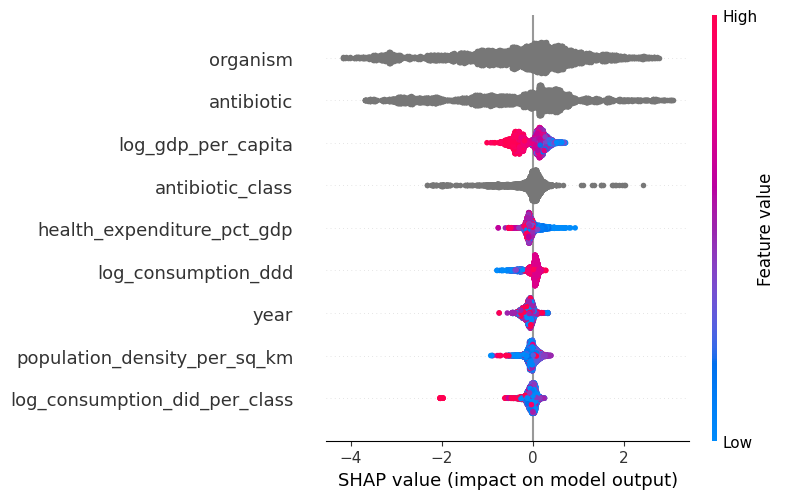

✅ Saved shap_summary.png


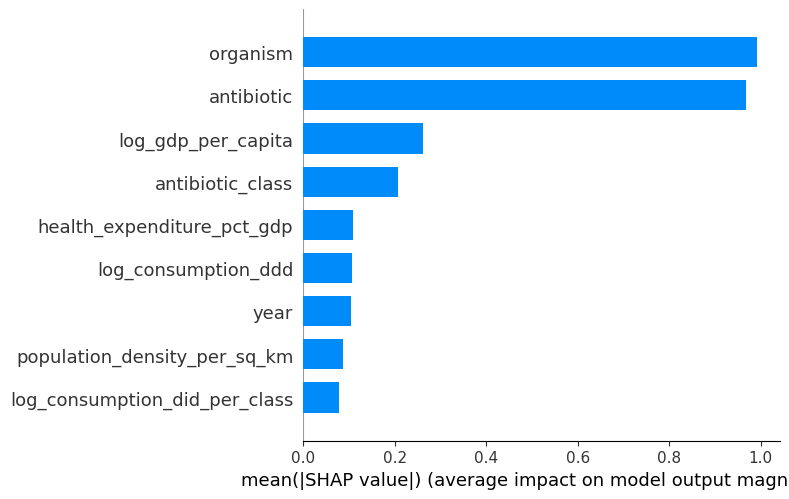

✅ Saved shap_bar.png


<Figure size 700x500 with 0 Axes>

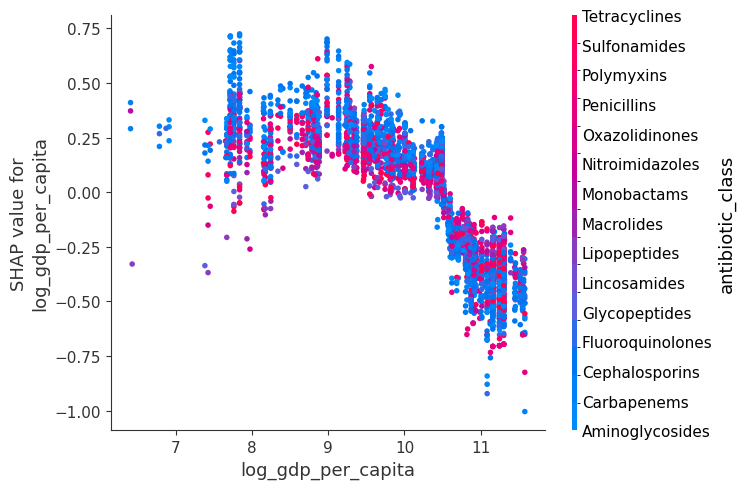

<Figure size 700x500 with 0 Axes>

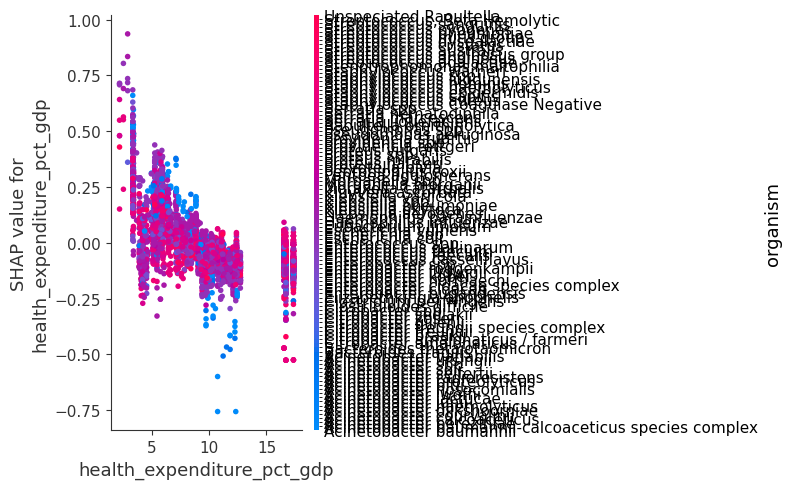

<Figure size 700x500 with 0 Axes>

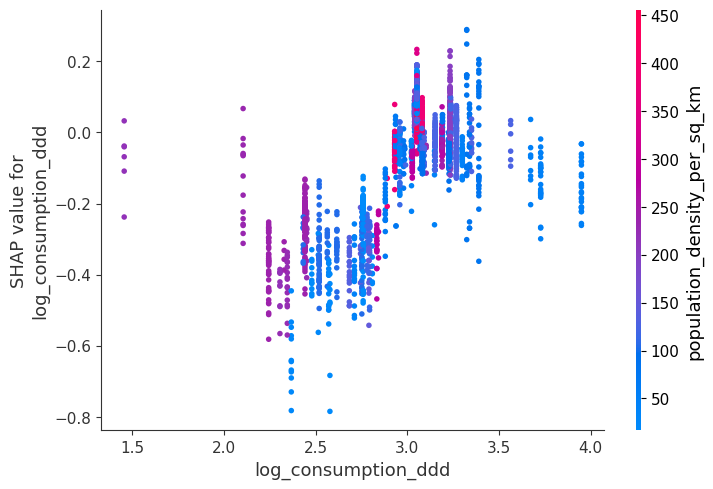

<Figure size 700x500 with 0 Axes>

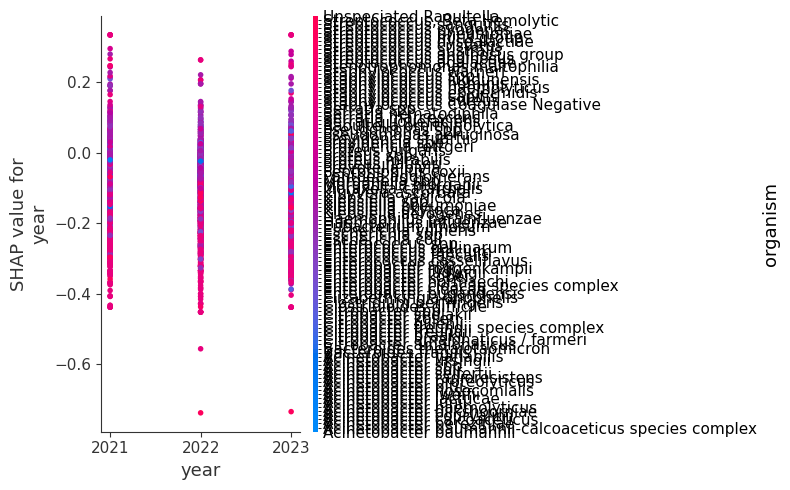

<Figure size 700x500 with 0 Axes>

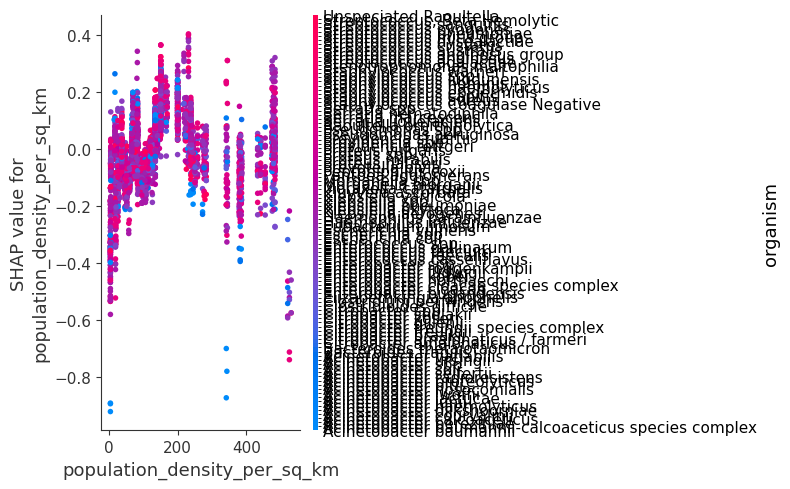

✅ Saved dependence plots for: ['log_gdp_per_capita', 'health_expenditure_pct_gdp', 'log_consumption_ddd', 'year', 'population_density_per_sq_km']

Per-organism mean |SHAP| breakdown:


ValueError: Grouper for 'organism' not 1-dimensional

In [6]:
# ANALYSIS: Retrain + Feature Importance + SHAP + Confusion Matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
import os

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
full_df = pd.read_csv('/kaggle/input/datasets/user/full-df/full_amr_with_macro.csv',
                      low_memory=False)

EXCLUDE_COUNTRIES = ['Kazakhstan', 'Russia', 'Belarus', 'Ukraine']
TEMPORAL_CUTOFF   = 2020
ES_VAL_YEARS      = [2019, 2020]

source_df = full_df[~full_df['country'].isin(EXCLUDE_COUNTRIES)].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

y_source         = source_df['resistance'].values
SCALE_POS_WEIGHT = (y_source == 0).sum() / (y_source == 1).sum()
print(f"SCALE_POS_WEIGHT: {SCALE_POS_WEIGHT:.4f}")

# ── Helper
def make_pool(df, has_labels=True):
    X = df[FEATURES].copy()
    for col in CAT_FEATURES:
        X[col] = X[col].fillna('unknown').astype(str)
    if has_labels:
        return Pool(data=X, label=df['resistance'].values, cat_features=CAT_FEATURES)
    return Pool(data=X, cat_features=CAT_FEATURES)

def get_X(df):
    X = df[FEATURES].copy()
    for col in CAT_FEATURES:
        X[col] = X[col].fillna('unknown').astype(str)
    return X

# STEP 1 — Retrain with correct temporal split
print("\n--- Step 1: Retrain with temporal split ---")

es_val_df   = source_df[source_df['year'].isin(ES_VAL_YEARS)].copy()
es_train_df = source_df[
    (source_df['year'] <= TEMPORAL_CUTOFF) &
    (~source_df['year'].isin(ES_VAL_YEARS))
].copy()
test_df     = source_df[source_df['year'] > TEMPORAL_CUTOFF].copy()

print(f"ES train : {len(es_train_df):,} | ES val : {len(es_val_df):,} | Test : {len(test_df):,}")

CATBOOST_PARAMS = {
    'learning_rate':         0.03,
    'depth':                 7,
    'reg_lambda':            3,
    'eval_metric':           'AUC',
    'random_seed':           42,
    'verbose':               200,
    'early_stopping_rounds': 100,
    'iterations':            5000,
    'task_type':             'GPU',
    'scale_pos_weight':      SCALE_POS_WEIGHT,
}

# Stage 1 — calibrate iterations
cal_model = CatBoostClassifier(**CATBOOST_PARAMS)
cal_model.fit(make_pool(es_train_df), eval_set=make_pool(es_val_df))
FINAL_ROUNDS = cal_model.best_iteration_
print(f"Calibrated FINAL_ROUNDS: {FINAL_ROUNDS}")

# Stage 2 — retrain on all data ≤ 2020
final_train_df = source_df[source_df['year'] <= TEMPORAL_CUTOFF].copy()
final_params   = {**CATBOOST_PARAMS,
                  'iterations': FINAL_ROUNDS,
                  'early_stopping_rounds': None,
                  'verbose': 100}

model = CatBoostClassifier(**final_params)
model.fit(make_pool(final_train_df))
model.save_model(f'{OUTPUT_DIR}/catboost_retrained.cbm')
print(" Retrained model saved")

# Test set evaluation
y_te     = test_df['resistance'].values
y_prob   = model.predict_proba(make_pool(test_df))[:, 1]
auc_te   = roc_auc_score(y_te, y_prob)
auprc_te = average_precision_score(y_te, y_prob)
print(f"\nTest AUC  : {auc_te:.4f}")
print(f"Test AUPRC: {auprc_te:.4f}")

print("\n--- Step 2: Feature Importance ---")

fi = pd.Series(
    model.get_feature_importance(),
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(FEATURES) * 0.35)))
colors = ['#d62728' if f in CAT_FEATURES else '#1f77b4' for f in fi.index]
fi.plot(kind='barh', ax=ax, color=colors[::-1])
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1f77b4', label='Numeric'),
    Patch(color='#d62728', label='Categorical'),
], loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150)
plt.show()
print(" Saved feature_importance.png")


print("\n--- Step 3: SHAP ---")

# Sample for speed — SHAP is slow on millions of rows
SHAP_SAMPLE = min(5000, len(test_df))
shap_df     = test_df.sample(SHAP_SAMPLE, random_state=42)
X_shap      = get_X(shap_df)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# ── 3a. Summary plot (beeswarm) ───────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES,
                  show=False, max_display=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved shap_summary.png")

# ── 3b. Bar plot (mean |SHAP|) ────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES,
                  plot_type='bar', show=False, max_display=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved shap_bar.png")

# ── 3c. Dependence plots — top 5 numeric features ────────────────────────────
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
num_features  = [f for f in mean_abs_shap.sort_values(ascending=False).index
                 if f not in CAT_FEATURES][:5]

for feat in num_features:
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(feat, shap_values, X_shap,
                         feature_names=FEATURES, show=False)
    plt.tight_layout()
    fname = feat.replace('/', '_').replace(' ', '_')
    plt.savefig(f'{OUTPUT_DIR}/shap_dep_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f" Saved dependence plots for: {num_features}")

# ── 3d. Per-organism SHAP breakdown ──────────────────────────────────────────
print("\nPer-organism mean |SHAP| breakdown:")
shap_org_df          = shap_df[['organism']].copy().reset_index(drop=True)
shap_org_df['y']     = shap_df['resistance'].values
shap_abs             = pd.DataFrame(np.abs(shap_values),
                                    columns=FEATURES).reset_index(drop=True)
shap_org_df          = pd.concat([shap_org_df, shap_abs], axis=1)

org_shap = (shap_org_df.groupby('organism')[FEATURES]
            .mean()
            .sort_values(FEATURES[0], ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
org_shap[num_features].plot(kind='bar', ax=ax)
ax.set_xlabel('Organism')
ax.set_ylabel('Mean |SHAP|')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_per_organism.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved shap_per_organism.png")

# ── 3e. Per-antibiotic SHAP breakdown ────────────────────────────────────────
shap_ab_df = shap_df[['antibiotic']].copy().reset_index(drop=True)
shap_ab_df = pd.concat([shap_ab_df, shap_abs], axis=1)

ab_shap = (shap_ab_df.groupby('antibiotic')[FEATURES]
           .mean()
           .sort_values(FEATURES[0], ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
ab_shap[num_features].plot(kind='bar', ax=ax)
ax.set_xlabel('Antibiotic')
ax.set_ylabel('Mean |SHAP|')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_per_antibiotic.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved shap_per_antibiotic.png")

print("\n--- Step 4: Confusion Matrix ---")

# Use 0.5 threshold — you can adjust based on clinical preference
THRESHOLD = 0.5
y_pred    = (y_prob >= THRESHOLD).astype(int)
cm        = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 4a. Raw counts ────────────────────────────────────────────────────────────
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Susceptible', 'Resistant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (threshold={THRESHOLD})')

# ── 4b. Normalized ────────────────────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_n  = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                  display_labels=['Susceptible', 'Resistant'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues',
            values_format='.2%')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"  Sensitivity (recall) : {tp/(tp+fn):.4f}")
print(f"  Specificity          : {tn/(tn+fp):.4f}")
print(f"  PPV (precision)      : {tp/(tp+fp):.4f}")
print(f"  NPV                  : {tn/(tn+fn):.4f}")
print("✅ Saved confusion_matrix.png")

# ── 4c. ROC + PR curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_te:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_te, y_prob)
axes[1].plot(rec, prec, lw=2, label=f'AUPRC = {auprc_te:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved roc_pr_curves.png")

print(f"\n✅ All outputs saved to {OUTPUT_DIR}")


--- Step 4: Confusion Matrix ---


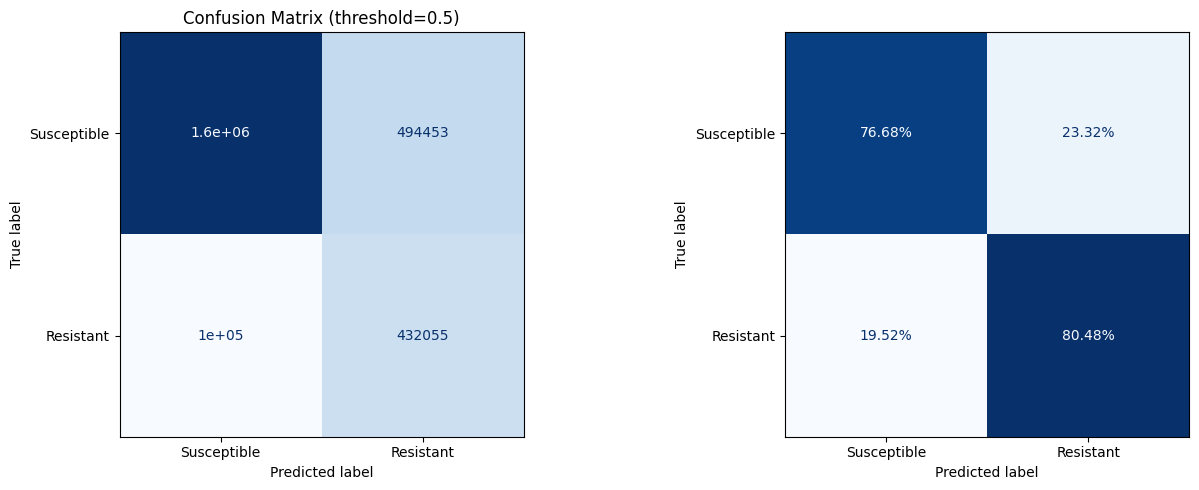

  TP=432,055  FP=494,453  FN=104,800  TN=1,626,099
  Sensitivity (recall) : 0.8048
  Specificity          : 0.7668
  PPV (precision)      : 0.4663
  NPV                  : 0.9395
✅ Saved confusion_matrix.png


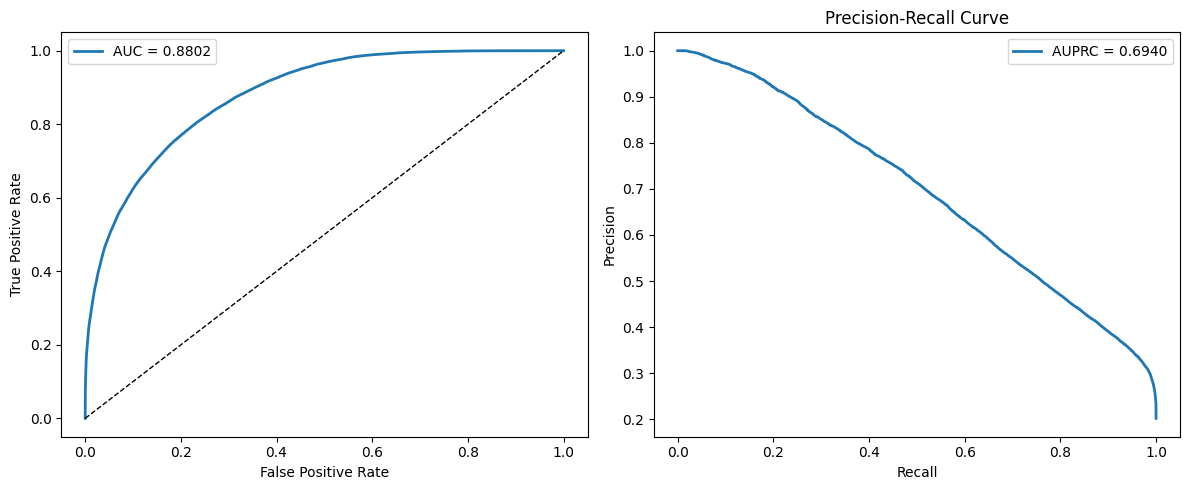

✅ Saved roc_pr_curves.png

✅ All outputs saved to /kaggle/working


In [7]:
print("\n--- Step 4: Confusion Matrix ---")

# Use 0.5 threshold — you can adjust based on clinical preference
THRESHOLD = 0.5
y_pred    = (y_prob >= THRESHOLD).astype(int)
cm        = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 4a. Raw counts ────────────────────────────────────────────────────────────
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Susceptible', 'Resistant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (threshold={THRESHOLD})')

# ── 4b. Normalized ────────────────────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_n  = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                  display_labels=['Susceptible', 'Resistant'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues',
            values_format='.2%')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print(f"  Sensitivity (recall) : {tp/(tp+fn):.4f}")
print(f"  Specificity          : {tn/(tn+fp):.4f}")
print(f"  PPV (precision)      : {tp/(tp+fp):.4f}")
print(f"  NPV                  : {tn/(tn+fn):.4f}")
print("✅ Saved confusion_matrix.png")

# ── 4c. ROC + PR curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {auc_te:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_te, y_prob)
axes[1].plot(rec, prec, lw=2, label=f'AUPRC = {auprc_te:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved roc_pr_curves.png")

print(f"\n All outputs saved to {OUTPUT_DIR}")

## 8. LOCO Validation (Leave-One-Country-Out)


In [ ]:
# 8. LOCO Validation — CatBoost with Per-Fold Early Stopping


import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score
import os

print("=== LOCO Validation — CatBoost + Per-Fold Early Stopping ===")

# ── Load data ─────────────────────────────────────────────────────────────────
full_df = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)

PROXY_COUNTRIES   = ['Bulgaria', 'Turkey', 'Mexico', 'Estonia', 'Lithuania', 'Latvia']
EXCLUDE_COUNTRIES = ['Kazakhstan', 'Russia', 'Belarus', 'Ukraine']
TEMPORAL_CUTOFF   = 2020
ES_VAL_YEARS      = [2019, 2020]

source_df = full_df[~full_df['country'].isin(EXCLUDE_COUNTRIES)].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

y_source = source_df['resistance'].values
SCALE_POS_WEIGHT = (y_source == 0).sum() / (y_source == 1).sum()
print(f"SCALE_POS_WEIGHT: {SCALE_POS_WEIGHT:.4f}")

CATBOOST_PARAMS = {
    'learning_rate':         0.03,
    'depth':                 7,
    'l2_leaf_reg':           3,
    'eval_metric':           'AUC',
    'random_seed':           42,
    'verbose':               200,
    'early_stopping_rounds': 100,
    'iterations':            5000,
    'task_type':             'GPU',
    'scale_pos_weight':      SCALE_POS_WEIGHT,
}

def make_pool(df):
    X = df[FEATURES].copy()
    for col in CAT_FEATURES:
        X[col] = X[col].fillna('unknown').astype(str)
    y = df['resistance'].values
    return Pool(data=X, label=y, cat_features=CAT_FEATURES)

print(f"Source domain      : {source_df['country'].nunique()} countries | {len(source_df):,} rows")
print(f"Excluded countries : {EXCLUDE_COUNTRIES}")
print(f"Proxy countries    : {PROXY_COUNTRIES}")

# ── Main LOCO Loop with per-fold early stopping
loco_results   = []
all_loco_preds = []

for test_country in PROXY_COUNTRIES:

    domain_df   = source_df[source_df['country'] != test_country].copy()

    es_val_df   = domain_df[domain_df['year'].isin(ES_VAL_YEARS)].copy()
    es_train_df = domain_df[
        (domain_df['year'] <= TEMPORAL_CUTOFF) &
        (~domain_df['year'].isin(ES_VAL_YEARS))
    ].copy()

    test_df = source_df[
        (source_df['country'] == test_country) &
        (source_df['year'] > TEMPORAL_CUTOFF)
    ].copy()

    if len(test_df) < 200:
        print(f"LOCO {test_country:12s} — skipped (only {len(test_df)} post-{TEMPORAL_CUTOFF} rows)")
        continue
    if len(es_val_df) < 200:
        print(f"LOCO {test_country:12s} — skipped (ES val too small: {len(es_val_df)} rows)")
        continue

    print(f"\nLOCO {test_country} | train={len(es_train_df):,} | es_val={len(es_val_df):,} | test={len(test_df):,}")

    train_pool = make_pool(es_train_df)
    val_pool   = make_pool(es_val_df)
    test_pool  = make_pool(test_df)
    y_te       = test_df['resistance'].values

    model_loco = CatBoostClassifier(**CATBOOST_PARAMS)
    model_loco.fit(train_pool, eval_set=val_pool)

    best_iter = model_loco.best_iteration_
    y_prob    = model_loco.predict_proba(test_pool)[:, 1]

    auc   = roc_auc_score(y_te, y_prob)            if y_te.std() > 0 else np.nan
    auprc = average_precision_score(y_te, y_prob)   if y_te.std() > 0 else np.nan

    loco_results.append({
        'country':        test_country,
        'n_es_train':     len(es_train_df),
        'n_es_val':       len(es_val_df),
        'n_test':         len(test_df),
        'best_iteration': best_iter,
        'test_years':     f">{TEMPORAL_CUTOFF}",
        'AUC':            auc,
        'AUPRC':          auprc,
    })

    pred_df = test_df[['country', 'organism', 'antibiotic',
                        'antibiotic_class', 'resistance', 'year']].copy()
    pred_df['pred_proba'] = y_prob
    pred_df['pred_label'] = (y_prob >= 0.5).astype(int)
    all_loco_preds.append(pred_df)

    print(f"  → AUC: {auc:.4f} | AUPRC: {auprc:.4f} | best_iter: {best_iter}")

loco_df       = pd.DataFrame(loco_results)
loco_preds_df = pd.concat(all_loco_preds, ignore_index=True)

print(f"\n{'Country':<14} {'AUC':>6} {'AUPRC':>7} {'BestIter':>9} {'N_test':>8}")
print("-" * 50)
for _, r in loco_df.iterrows():
    print(f"{r['country']:<14} {r['AUC']:>6.4f} {r['AUPRC']:>7.4f} "
          f"{int(r['best_iteration']):>9} {int(r['n_test']):>8,}")

print(f"\nMean LOCO AUC  : {loco_df['AUC'].mean():.4f} ± {loco_df['AUC'].std():.4f}")
print(f"Mean LOCO AUPRC: {loco_df['AUPRC'].mean():.4f} ± {loco_df['AUPRC'].std():.4f}")
print(f"Best iter range: {loco_df['best_iteration'].min():.0f} – "
      f"{loco_df['best_iteration'].max():.0f}")

os.makedirs('/kaggle/working', exist_ok=True)
loco_df.to_csv('/kaggle/working/loco_final_results.csv', index=False)
loco_preds_df.to_csv('/kaggle/working/loco_predictions.csv', index=False)
print(f"\n Saved loco_final_results.csv and loco_predictions.csv | {len(loco_preds_df):,} rows")

=== LOCO Validation — CatBoost + Per-Fold Early Stopping ===
SCALE_POS_WEIGHT: 4.3553
Source domain      : 82 countries | 12,082,868 rows
Excluded countries : ['Kazakhstan', 'Russia', 'Belarus', 'Ukraine']
Proxy countries    : ['Bulgaria', 'Turkey', 'Mexico', 'Estonia', 'Lithuania', 'Latvia']

LOCO Bulgaria | train=7,654,005 | es_val=1,754,481 | test=6,680
0:	test: 0.8023872	best: 0.8023872 (0)	total: 4.5s	remaining: 6h 14m 49s
200:	test: 0.8765699	best: 0.8765699 (200)	total: 12m 46s	remaining: 5h 4m 48s
400:	test: 0.8804510	best: 0.8804598 (399)	total: 26m 25s	remaining: 5h 3m 7s
600:	test: 0.8820250	best: 0.8820250 (600)	total: 40m 19s	remaining: 4h 55m 9s
800:	test: 0.8827694	best: 0.8827836 (797)	total: 54m 44s	remaining: 4h 46m 59s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.882926255
bestIteration = 885

Shrink model to first 886 iterations.
  → AUC: 0.8319 | AUPRC: 0.7653 | best_iter: 885

LOCO Turkey | train=7,547,423 | es_val=1,724,364 | test=51,869
0

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

loco_preds_df = pd.read_csv('/kaggle/working/loco_predictions.csv')

rows = []
for (country, organism), grp in loco_preds_df.groupby(['country', 'organism']):
    if len(grp) < 100 or grp['resistance'].nunique() < 2:
        continue
    auc   = roc_auc_score(grp['resistance'], grp['pred_proba'])
    auprc = average_precision_score(grp['resistance'], grp['pred_proba'])
    rows.append({
        'country':  country,
        'organism': organism,
        'n':        len(grp),
        'AUC':      round(auc, 4),
        'AUPRC':    round(auprc, 4),
        'R_rate':   round(grp['resistance'].mean(), 4),
    })

org_df = pd.DataFrame(rows).sort_values(['country', 'AUC'])
print(org_df.to_string(index=False))
org_df.to_csv('/kaggle/working/loco_organism_breakdown.csv', index=False)

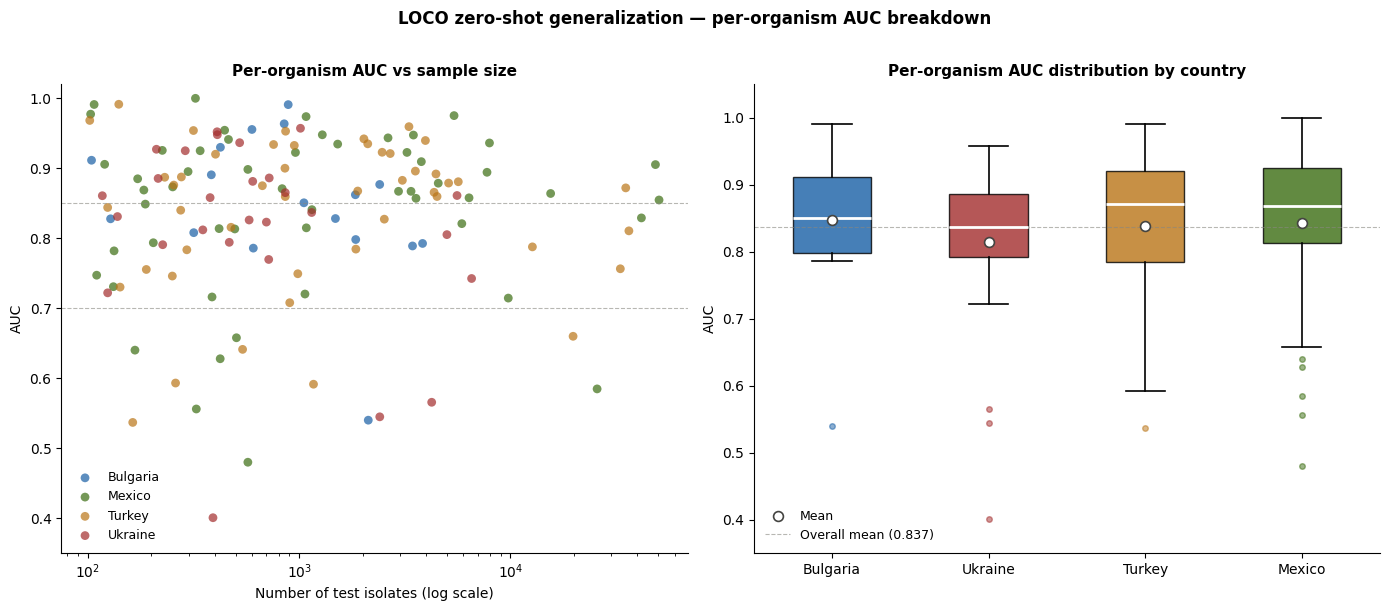

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

org_df = pd.read_csv('/kaggle/working/loco_organism_breakdown.csv')

# ── Figure A: Scatter AUC vs n_test (per organism per country) ───────────────
country_colors = {
    'Bulgaria': '#185FA5',
    'Ukraine':  '#A32D2D',
    'Turkey':   '#BA7517',
    'Mexico':   '#3B6D11',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# --- Scatter: AUC vs sample size ---
ax = axes[0]
for country, grp in org_df.groupby('country'):
    ax.scatter(grp['n'], grp['AUC'],
               color=country_colors[country], alpha=0.7,
               s=40, label=country, edgecolors='none')

ax.axhline(0.7,  color='#888780', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(0.85, color='#888780', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('Number of test isolates (log scale)', fontsize=10)
ax.set_ylabel('AUC', fontsize=10)
ax.set_title('Per-organism AUC vs sample size', fontsize=11, fontweight='bold')
ax.set_ylim(0.35, 1.02)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, frameon=False)

# --- Box plot: AUC distribution per country ---
ax = axes[1]
countries = ['Bulgaria', 'Ukraine', 'Turkey', 'Mexico']
data_box  = [org_df[org_df['country'] == c]['AUC'].values for c in countries]
colors    = [country_colors[c] for c in countries]

bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

# Overlay mean
means = [org_df[org_df['country'] == c]['AUC'].mean() for c in countries]
ax.scatter(range(1, 5), means, color='white', s=50, zorder=5,
           edgecolors='#444441', linewidths=1.2, label='Mean')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(countries, fontsize=10)
ax.set_ylabel('AUC', fontsize=10)
ax.set_title('Per-organism AUC distribution by country', fontsize=11, fontweight='bold')
ax.set_ylim(0.35, 1.05)
ax.axhline(org_df['AUC'].mean(), color='#888780',
           linestyle='--', linewidth=0.8, alpha=0.6, label=f'Overall mean ({org_df["AUC"].mean():.3f})')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, frameon=False)

plt.suptitle('LOCO zero-shot generalization — per-organism AUC breakdown',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_loco_scatter_box.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_loco_scatter_box.png', bbox_inches='tight', dpi=300)
plt.show()

In [27]:
from scipy import stats

# Per-organism error = 1 - AUC
org_df['error'] = 1 - org_df['AUC']

# Correlation per country
print("Pearson correlation (error vs log n):")
for country, grp in org_df.groupby('country'):
    r, p = stats.pearsonr(np.log(grp['n']), grp['error'])
    print(f"  {country:<10} r={r:.3f}  p={p:.4f}  n_organisms={len(grp)}")

print("\nSpearman correlation (error vs n):")
for country, grp in org_df.groupby('country'):
    r, p = stats.spearmanr(grp['n'], grp['error'])
    print(f"  {country:<10} r={r:.3f}  p={p:.4f}")

Pearson correlation (error vs log n):
  Bulgaria   r=0.351  p=0.1667  n_organisms=17
  Mexico     r=-0.065  p=0.6428  n_organisms=53
  Turkey     r=-0.065  p=0.6661  n_organisms=47
  Ukraine    r=0.257  p=0.1962  n_organisms=27

Spearman correlation (error vs n):
  Bulgaria   r=0.419  p=0.0940
  Mexico     r=-0.024  p=0.8651
  Turkey     r=-0.050  p=0.7400
  Ukraine    r=0.157  p=0.4345


## 9. 5-Fold Time-Aware Cross-Validation

Folds constructed chronologically by year quantiles.
Isolate ID group constraints prevent the same isolate appearing in both train and validation within any fold.


In [29]:
print(cv_df[['fold', 'train_years', 'val_years', 'train_size', 'val_size', 'AUC', 'AUPRC']].to_string(index=False))
print(f"\nMean AUC  : {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")
print(f"Mean AUPRC: {cv_df['AUPRC'].mean():.4f} ± {cv_df['AUPRC'].std():.4f}")

 fold train_years val_years  train_size  val_size      AUC    AUPRC
    1   2004–2006 2007–2009      582250    945615 0.896894 0.741496
    2   2004–2009 2010–2012     1527865   1024457 0.876975 0.678535
    3   2004–2012 2013–2015     2552322   2366206 0.889039 0.674899
    4   2004–2015 2016–2018     4918528   2925732 0.867583 0.633590
    5   2004–2018 2019–2021     7844260   2738172 0.875951 0.654516

Mean AUC  : 0.8813 ± 0.0116
Mean AUPRC: 0.6766 ± 0.0405


## 10. Kazakhstan Macroeconomic Data Processing

Kazakhstan-specific antibiotic consumption (DID per 1000/day, 2017–2023) merged with Kazakhstan World Bank macro indicators.
This dataset is used **exclusively for zero-shot inference** — never seen during model training.


In [11]:
# =============================================================================
# 10. Kazakhstan Macroeconomic Data Processing (FIXED)
# =============================================================================

KZ_MACRO_FILES = {
    'gdp_per_capita_usd':         '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv',
    'health_expenditure_pct_gdp': '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv',
    'population_total':           '/kaggle/input/datasets/uaisamangeldi/macro-kz/API_SP.POP.TOTL_DS2_en_csv_v2_61/API_SP.POP.TOTL_DS2_en_csv_v2_61.csv',
}
KZ_DID_PATH = '/kaggle/input/datasets/uaisamangeldi/kz-data/kazakhstan_antibiotics_did_2017_2023.csv'
KZ_AREA_KM2 = 2_724_900

def load_kz_wb_indicator(path, col_name):
    df = pd.read_csv(path, skiprows=4)
    df.columns = df.columns.str.strip()
    df = df[df['Country Name'] == 'Kazakhstan'].copy()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df = df.melt(id_vars=['Country Name'], value_vars=year_cols, var_name='year', value_name=col_name)
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year', col_name])
    df['year'] = df['year'].astype(int)
    return df[['year', col_name]]

# World Bank macros
kz_macro = load_kz_wb_indicator(KZ_MACRO_FILES['gdp_per_capita_usd'], 'gdp_per_capita_usd')
for col, path in list(KZ_MACRO_FILES.items())[1:]:
    kz_macro = kz_macro.merge(load_kz_wb_indicator(path, col), on='year', how='outer')

kz_macro = kz_macro.sort_values('year').reset_index(drop=True)
kz_macro['population_density_per_sq_km'] = kz_macro['population_total'] / KZ_AREA_KM2

# Load KZ DID
kz_did = pd.read_csv(KZ_DID_PATH)
kz_did.columns = kz_did.columns.str.strip()
kz_did['antibiotic']     = kz_did['antibiotic'].str.strip().str.lower().str.replace('/', ' / ', regex=False)
kz_did['aware_category'] = kz_did['aware_category'].fillna('Unknown').str.strip()
kz_did['did']            = pd.to_numeric(kz_did['did'], errors='coerce').fillna(0)
kz_did['year']           = kz_did['year'].astype(int)

# =============================================================================
# FIX: Compute consumption_did_per_class for KZ
# Mirrors what Cell 9 does for global data:
#   aggregate DID by (year, antibiotic_class) → one value per class per year
# aware_category in KZ DID maps directly to antibiotic_class in global data
# =============================================================================
kz_class_did = (
    kz_did
    .groupby(['year', 'aware_category'])['did']
    .sum()
    .reset_index()
    .rename(columns={'aware_category': 'antibiotic_class',
                     'did': 'consumption_did_per_class'})
)

# Also compute total consumption (sum across all classes per year)
kz_total_did = (
    kz_did
    .groupby('year')['did']
    .sum()
    .reset_index()
    .rename(columns={'did': 'consumption_ddd_total'})
)

# Merge macro + total consumption
kz_macro_filtered = kz_macro[(kz_macro['year'] >= 2017) & (kz_macro['year'] <= 2023)].copy()
kz_macro_filtered = kz_macro_filtered.merge(kz_total_did, on='year', how='left')

# Now join antibiotic-level DID with macro
# Result: one row per (antibiotic, year) with its class-level DID populated
kz_final = kz_did.merge(kz_macro_filtered, on='year', how='inner')

# Map aware_category → antibiotic_class (same column name as in global training data)
kz_final = kz_final.rename(columns={'aware_category': 'antibiotic_class'})

# Merge in class-level DID
kz_final = kz_final.merge(kz_class_did, on=['year', 'antibiotic_class'], how='left')

# Fill any missing class-DID with the KZ mean (e.g. 'Unknown' category)
# Back-transform log_consumption_did_per_class to get the raw mean for fallback imputation
# Fill any missing class-DID with global mean fallback
global_mean_did = np.expm1(full_df['log_consumption_did_per_class'].mean())
kz_final['consumption_did_per_class'] = kz_final['consumption_did_per_class'].fillna(global_mean_did)

# Log transforms (must happen BEFORE dropping raw columns)
kz_final['log_gdp_per_capita']            = np.log1p(kz_final['gdp_per_capita_usd'].clip(lower=0))
kz_final['log_consumption_ddd']           = np.log1p(kz_final['consumption_ddd_total'].clip(lower=0))
kz_final['log_consumption_did_per_class'] = np.log1p(kz_final['consumption_did_per_class'].clip(lower=0))

# Drop raw versions (log columns are what goes into FEATURES)
kz_final = kz_final.drop(columns=['gdp_per_capita_usd', 'consumption_ddd_total', 'consumption_did_per_class'])
kz_final = kz_final.sort_values(['year', 'antibiotic']).reset_index(drop=True)

# Verify — reference log columns, not raw
log_cols = ['log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class']
print(f"Kazakhstan inference dataset: {kz_final.shape}")
print(f"\nLog feature coverage (non-null %):")
print((kz_final[log_cols].notna().mean() * 100).round(1))
print(f"\nSample:")
print(kz_final[['year', 'antibiotic', 'antibiotic_class'] + log_cols].head(6).to_string(index=False))

kz_final.to_csv('/kaggle/working/kazakhstan_final_prediction_input_2017_2023.csv', index=False)
print("\nSaved.")

Kazakhstan inference dataset: (183, 11)

Log feature coverage (non-null %):
log_gdp_per_capita               100.0
log_consumption_ddd              100.0
log_consumption_did_per_class    100.0
dtype: float64

Sample:
 year                    antibiotic antibiotic_class  log_gdp_per_capita  log_consumption_ddd  log_consumption_did_per_class
 2017                      amikacin           Access            9.098748             1.391033                       0.776109
 2017                   amoxicillin           Access            9.098748             1.391033                       0.776109
 2017 amoxicillin / clavulanic acid           Access            9.098748             1.391033                       0.776109
 2017                    ampicillin           Access            9.098748             1.391033                       0.776109
 2017                  azithromycin            Watch            9.098748             1.391033                       1.045563
 2017              benzylpenicill

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use per-class DID as the primary AMR-pressure signal,
# combined with macro features as structural context
country_profile = full_df.groupby('country').agg(
    log_gdp            = ('log_gdp_per_capita',           'mean'),
    health_exp         = ('health_expenditure_pct_gdp',   'mean'),
    pop_density        = ('population_density_per_sq_km', 'mean'),
    log_cons_total     = ('log_consumption_ddd',          'mean'),
    log_cons_per_class = ('log_consumption_did_per_class','mean'),
).reset_index().set_index('country')

kz_profile = pd.DataFrame([{
    'log_gdp':            kz_final['log_gdp_per_capita'].mean(),
    'health_exp':         kz_final['health_expenditure_pct_gdp'].mean(),
    'pop_density':        kz_final['population_density_per_sq_km'].mean(),
    'log_cons_total':     kz_final['log_consumption_ddd'].mean(),
    'log_cons_per_class': kz_final['log_consumption_did_per_class'].mean(),
}], index=['Kazakhstan'])

country_profile = pd.concat([country_profile, kz_profile])

print(f"Total countries for clustering : {len(country_profile)}")
print(f"Any NaNs in profile:\n"
      f"{country_profile.isna().sum()[country_profile.isna().sum() > 0]}")

# ── Impute any remaining NaNs with column mean
country_profile = country_profile.fillna(country_profile.mean())

# ── Scale and cluster
feature_cols = ['log_gdp', 'health_exp', 'pop_density', 'log_cons_total', 'log_cons_per_class']
scaler    = StandardScaler()
X_cluster = scaler.fit_transform(country_profile[feature_cols])

kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
country_profile['cluster'] = kmeans.fit_predict(X_cluster)

kz_cluster = country_profile.loc['Kazakhstan', 'cluster']
kz_row     = country_profile.loc['Kazakhstan', feature_cols]

print(f"\nKazakhstan is in cluster {kz_cluster}")
print("\nKazakhstan feature profile:")
print(kz_row.to_string())

print("\nCountries in Kazakhstan's cluster:")
cluster_members = country_profile[country_profile['cluster'] == kz_cluster].drop(columns='cluster')
print(cluster_members.index.tolist())

print("\nCluster member profiles:")
print(cluster_members[feature_cols].to_string())

kz_scaled = scaler.transform(kz_row.values.reshape(1, -1))
centroid   = kmeans.cluster_centers_[kz_cluster]
distances  = {}
for country in cluster_members.index:
    row     = country_profile.loc[country, feature_cols].values.reshape(1, -1)
    scaled  = scaler.transform(row)
    distances[country] = np.linalg.norm(scaled - centroid)

dist_df = pd.Series(distances).sort_values().rename('distance_to_centroid')
print("\nDistance to cluster centroid (lower = more central):")
print(dist_df.to_string())

# ── Post-Soviet check
check = ['Russia', 'Ukraine', 'Belarus', 'Lithuania', 'Latvia', 'Estonia']
ps_df = country_profile[country_profile.index.isin(check)][['cluster']]
print("\nPost-Soviet cluster assignments:")
print(ps_df.to_string())

# ── Save
os.makedirs('/kaggle/working', exist_ok=True)
country_profile.to_csv('/kaggle/working/country_clusters.csv')
print("\n✅ Saved country_clusters.csv")

Total countries for clustering : 86
Any NaNs in profile:
Series([], dtype: int64)

Kazakhstan is in cluster 5

Kazakhstan feature profile:
log_gdp               9.192614
health_exp            3.309739
pop_density           7.097607
log_cons_total        2.067830
log_cons_per_class    1.418312

Countries in Kazakhstan's cluster:
['Qatar', 'Kazakhstan']

Cluster member profiles:
              log_gdp  health_exp  pop_density  log_cons_total  log_cons_per_class
Qatar       11.167352    2.927435   230.868025         1.97994            0.844860
Kazakhstan   9.192614    3.309739     7.097607         2.06783            1.418312

Distance to cluster centroid (lower = more central):
Kazakhstan    1.473601
Qatar         1.473601

Post-Soviet cluster assignments:
           cluster
Belarus          4
Estonia          0
Latvia           1
Lithuania        0
Russia           0
Ukraine          4

✅ Saved country_clusters.csv


## 11. Zero-Shot Prediction for Kazakhstan

Model trained exclusively on non-Kazakh global data, applied to Kazakhstan using macroeconomic proxy features.
A prediction grid crosses Kazakhstan antibiotic-year rows with 6 target pathogen species.

**Encoding:** Fit on source training data only. KZ antibiotic names normalized to lowercase to ensure
vocabulary alignment. Unknown labels mapped to -1.


In [17]:
source_df  = pd.read_csv('/kaggle/working/full_amr_with_macro.csv', low_memory=False)
kz_base_df = pd.read_csv('/kaggle/working/kazakhstan_final_prediction_input_2017_2023.csv')

source_df = source_df[~source_df['country'].isin(['Kazakhstan'])].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

source_df['antibiotic'] = (source_df['antibiotic']
                           .astype(str).str.strip().str.lower()
                           .str.replace('/', ' / ', regex=False)
                           .str.replace(r'\s+', ' ', regex=True)
                           .str.strip())

TARGET_ORGANISMS = [
    'Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus',
    'Pseudomonas aeruginosa', 'Acinetobacter baumannii', 'Enterococcus faecium'
]

prediction_rows = []
for _, row in kz_base_df.iterrows():
    for org in TARGET_ORGANISMS:
        new_row = row.to_dict()
        new_row['organism'] = org
        prediction_rows.append(new_row)

kz_df = pd.DataFrame(prediction_rows)

kz_df['antibiotic'] = (kz_df['antibiotic']
                       .astype(str)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())

source_antibiotics = set(source_df['antibiotic'].unique())
kz_antibiotics_raw = set(kz_df['antibiotic'].unique())

print("=== ANTIBIOTIC VOCABULARY INVESTIGATION ===")
print(f"Source database unique antibiotics: {len(source_antibiotics)}")
print(f"KZ DID unique antibiotics         : {len(kz_antibiotics_raw)}")

print("\nKZ antibiotic → Source match status:")
for ab in sorted(kz_antibiotics_raw):
    status = "✓ MATCHED" if ab in source_antibiotics else "✗ unmatched"
    print(f"  {status}: '{ab}'")

antibiotic_harmonize = {
    'amoxicillin / clavulanic acid':            'amoxicillin- clavulanic acid',
    'amoxicillin and beta-lactamase inhibitor': 'amoxicillin- clavulanic acid',
    'amoxicillin':                              'amoxycillin clavulanate',
    'imipenem / cilastatin':                    'imipenem',
    'sulfamethoxazole / trimethoprim':          'trimethoprim / sulfamethoxazole',
    'sulfamethoxazole and trimethoprim':        'trimethoprim / sulfamethoxazole',
    'vancomycin (iv)':                          'vancomycin',
    'fosfomycin (iv)':                          'fosfomycin',
    'benzylpenicillin':                         'penicillin',
    'cefpodoxime proxetil':                     'cefpodoxime',
}

kz_df['antibiotic'] = kz_df['antibiotic'].replace(antibiotic_harmonize)

kz_antibiotics_after = set(kz_df['antibiotic'].unique())
matched   = kz_antibiotics_after & source_antibiotics
unmatched = kz_antibiotics_after - source_antibiotics

print(f"\n=== VOCABULARY MATCH AFTER HARMONIZATION ===")
print(f"Matched  : {len(matched)}/{len(kz_antibiotics_after)} ({100*len(matched)/len(kz_antibiotics_after):.1f}%)")
print(f"Matched antibiotics  : {sorted(matched)}")
print(f"\nUnmatched (→ unknown): {sorted(unmatched)}")
print("\nNote: Unmatched antibiotics are regionally specific drugs absent from")
print("ATLAS/SIDERO-WT/KEYSTONE surveillance panels.")

encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    le.fit(source_df[col].fillna('unknown').astype(str))
    source_df[col] = le.transform(source_df[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    kz_df[col] = kz_df[col].fillna('unknown').astype(str).map(
        lambda s, d=le_dict: d.get(s, -1)
    )
    encoders[col] = le

X_source = source_df[FEATURES].copy()
y_source = source_df['resistance'].copy()
valid_mask = X_source.notna().all(axis=1)
X_source   = X_source[valid_mask]
y_source   = y_source[valid_mask]

print(f"\nTraining rows: {len(X_source):,}")
spw = (y_source == 0).sum() / (y_source == 1).sum()
print(f"scale_pos_weight: {spw:.2f}")

try:
    import pyopencl
    lgb_device = 'gpu'
except ImportError:
    lgb_device = 'cpu'

model_final = LGBMClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    scale_pos_weight=spw, importance_type='gain',
    device=lgb_device, random_state=42, verbose=-1
)
model_final.fit(X_source, y_source)
print("Model training complete.")


for col in NUM_FEATURES:
    if col in kz_df.columns:
        kz_df[col] = kz_df[col].fillna(
            source_df[col].mean() if col in source_df.columns else 0
        )

X_kz = kz_df[FEATURES].copy()
print(f"KZ NaN check: {X_kz.isna().sum().sum()} missing values")

kz_df['resistance_prob'] = model_final.predict_proba(X_kz)[:, 1]

for col in CAT_FEATURES:
    le = encoders[col]
    kz_df[col] = kz_df[col].apply(
        lambda x: le.inverse_transform([int(x)])[0] if x != -1 else 'unknown'
    )

top_risks = (
    kz_df.groupby(['organism', 'antibiotic'])['resistance_prob']
    .mean().reset_index()
    .sort_values('resistance_prob', ascending=False)
)

top_risks_matched = top_risks[top_risks['antibiotic'] != 'unknown']
top_risks_unknown = top_risks[top_risks['antibiotic'] == 'unknown']

print(f"\nMatched predictions  : {len(top_risks_matched)}")
print(f"Unknown predictions  : {len(top_risks_unknown)}")

print("\n--- Top 10: Matched Antibiotic Predictions ---")
print(top_risks_matched.head(10).to_string(index=False))

print("\n--- Unknown (driven by organism + macro features only) ---")
print(top_risks_unknown.head(6).to_string(index=False))

kz_df.to_csv('/kaggle/working/kz_zero_shot_predictions.csv', index=False)
top_risks.to_csv('/kaggle/working/kz_top_resistance_risks.csv', index=False)
top_risks_matched.to_csv('/kaggle/working/kz_top_resistance_risks_matched.csv', index=False)
print("\nPredictions saved.")

=== ANTIBIOTIC VOCABULARY INVESTIGATION ===
Source database unique antibiotics: 55
KZ DID unique antibiotics         : 41

KZ antibiotic → Source match status:
  ✓ MATCHED: 'amikacin'
  ✗ unmatched: 'amoxicillin'
  ✗ unmatched: 'amoxicillin / clavulanic acid'
  ✗ unmatched: 'amoxicillin and beta-lactamase inhibitor'
  ✓ MATCHED: 'ampicillin'
  ✓ MATCHED: 'azithromycin'
  ✗ unmatched: 'benzylpenicillin'
  ✗ unmatched: 'cefazolin'
  ✓ MATCHED: 'cefepime'
  ✓ MATCHED: 'cefixime'
  ✗ unmatched: 'cefotaxime'
  ✗ unmatched: 'cefpodoxime proxetil'
  ✓ MATCHED: 'ceftazidime'
  ✓ MATCHED: 'ceftriaxone'
  ✗ unmatched: 'cefuroxime'
  ✗ unmatched: 'chloramphenicol'
  ✓ MATCHED: 'ciprofloxacin'
  ✓ MATCHED: 'clarithromycin'
  ✓ MATCHED: 'doripenem'
  ✓ MATCHED: 'doxycycline'
  ✓ MATCHED: 'ertapenem'
  ✗ unmatched: 'fosfomycin (iv)'
  ✗ unmatched: 'furazidin'
  ✓ MATCHED: 'gentamicin'
  ✗ unmatched: 'imipenem / cilastatin'
  ✗ unmatched: 'kanamycin'
  ✓ MATCHED: 'levofloxacin'
  ✓ MATCHED: 'linezoli

In [21]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, classification_report
)

print("=== Kazakhstan Zero-Shot Prediction (CatBoost) ===")

# ── Load data ─────────────────────────────────────────────────────────────────
full_df  = pd.read_csv('/kaggle/input/datasets/user/full-df/full_amr_with_macro.csv', low_memory=False)
kz_final = pd.read_csv('/kaggle/input/datasets/user/kzzzzz/kazakhstan_final_prediction_input_2017_2023.csv', low_memory=False)

# ── Configuration ─────────────────────────────────────────────────────────────
EXCLUDE_COUNTRIES = ['Kazakhstan', 'Russia', 'Belarus', 'Ukraine']
TEMPORAL_CUTOFF   = 2020

TARGET_ORGANISMS = [
    'Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus',
    'Pseudomonas aeruginosa', 'Acinetobacter baumannii', 'Enterococcus faecium'
]
ANTIBIOTIC_TO_CLASS_MAP = {
    # Carbapenems
    'Meropenem': 'Carbapenems', 'Imipenem': 'Carbapenems',
    'Doripenem': 'Carbapenems', 'Ertapenem': 'Carbapenems',
    'Meropenem vaborbactam': 'Carbapenems',
    'Meropenem/ Vaborbactam at 8': 'Carbapenems',
    'Imipenem/ Relebactam': 'Carbapenems',
    # Fluoroquinolones
    'Ciprofloxacin': 'Fluoroquinolones', 'Levofloxacin': 'Fluoroquinolones',
    'Moxifloxacin': 'Fluoroquinolones',  'Ofloxacin': 'Fluoroquinolones',
    'Norfloxacin': 'Fluoroquinolones',
    # Cephalosporins
    'Ceftazidime': 'Cephalosporins',  'Cefepime': 'Cephalosporins',
    'Ceftriaxone': 'Cephalosporins',  'Cefixime': 'Cephalosporins',
    'Cefazolin': 'Cephalosporins',    'Cefotaxime': 'Cephalosporins',
    'Cefuroxime': 'Cephalosporins',   'Cefpodoxime': 'Cephalosporins',
    'Cefoxitin': 'Cephalosporins',    'Ceftolozane': 'Cephalosporins',
    'Ceftaroline': 'Cephalosporins',  'Ceftazidime avibactam': 'Cephalosporins',
    'Ceftolozane tazobactam': 'Cephalosporins', 'Cefiderocol': 'Cephalosporins',
    'Ceftazidime/ Avibactam': 'Cephalosporins', 'Ceftolozane/ Tazobactam': 'Cephalosporins',
    'Ceftibuten': 'Cephalosporins',
    # Aminoglycosides
    'Amikacin': 'Aminoglycosides',  'Gentamicin': 'Aminoglycosides',
    'Kanamycin': 'Aminoglycosides', 'Tobramycin': 'Aminoglycosides',
    'Netilmicin': 'Aminoglycosides',
    # Penicillins
    'Ampicillin': 'Penicillins',
    'Amoxicillin- clavulanic acid': 'Penicillins',
    'Amoxycillin clavulanate': 'Penicillins',
    'Amoxicillin-\nclavulanic acid': 'Penicillins',
    'Penicillin': 'Penicillins',
    'Piperacillin': 'Penicillins',
    'Piperacillin-tazobactam': 'Penicillins',
    'Piperacillin tazobactam': 'Penicillins',
    'Piperacillin-\ntazobactam': 'Penicillins',
    'Oxacillin': 'Penicillins',
    'Ampicillin sulbactam': 'Penicillins',
    'Ampicillin/ Sulbactam': 'Penicillins',
    # Macrolides
    'Azithromycin': 'Macrolides', 'Clarithromycin': 'Macrolides',
    'Erythromycin': 'Macrolides', 'Midecamycin': 'Macrolides',
    'Roxithromycin': 'Macrolides',
    # Glycopeptides
    'Vancomycin': 'Glycopeptides', 'Teicoplanin': 'Glycopeptides',
    # Tetracyclines
    'Doxycycline': 'Tetracyclines',  'Tetracycline': 'Tetracyclines',
    'Minocycline': 'Tetracyclines',  'Tigecycline': 'Tetracyclines',
    'Omadacycline': 'Tetracyclines',
    # Oxazolidinones
    'Linezolid': 'Oxazolidinones',
    # Polymyxins
    'Colistin': 'Polymyxins', 'Polymyxin B': 'Polymyxins',
    # Sulfonamides
    'Trimethoprim / sulfamethoxazole': 'Sulfonamides',
    'Trimethoprim-sulfamethoxazole':   'Sulfonamides',
    'Trimethoprim/ Sulfamethoxazole':  'Sulfonamides',
    'Trimethoprim sulfa':              'Sulfonamides',
    'Trimethoprim':                    'Sulfonamides',
    'Sulfasodimidine':                 'Sulfonamides',
    # Nitroimidazoles
    'Metronidazole': 'Nitroimidazoles',
    # Phosphonic acids
    'Fosfomycin': 'Phosphonic acids',
    # Amphenicols
    'Chloramphenicol': 'Amphenicols',
    'Thiamphenicol':   'Amphenicols',
    # Monobactams
    'Aztreonam': 'Monobactams', 'Aztreonam/ Avibactam': 'Monobactams',
    # Lincosamides
    'Clindamycin': 'Lincosamides',
    # Lipopeptides
    'Daptomycin': 'Lipopeptides',
    # Streptogramins
    'Quinupristin dalfopristin': 'Streptogramins',
    # Nitrofurans (regional KZ drugs)
    'Furazidin':     'Nitrofurans',
    'Nitrofurantoin': 'Nitrofurans',
    # Quinolines (regional KZ drugs)
    'Nitroxoline': 'Quinolines',
}
#lowercase variants
ANTIBIOTIC_TO_CLASS_MAP.update({
    k.lower(): v for k, v in list(ANTIBIOTIC_TO_CLASS_MAP.items())
})

MODEL_PATH = '/kaggle/working/catboost_retrained.cbm'
print(f"Loading model from {MODEL_PATH} ...")
model_final = CatBoostClassifier()
model_final.load_model(MODEL_PATH)
print(f"  Loaded — tree count: {model_final.tree_count_}")

def make_pool(df, has_labels=True):
    X = df[FEATURES].copy()
    for col in CAT_FEATURES:
        X[col] = X[col].fillna('unknown').astype(str)
    if has_labels:
        return Pool(data=X, label=df['resistance'].values, cat_features=CAT_FEATURES)
    return Pool(data=X, cat_features=CAT_FEATURES)

def print_metrics(y_true, y_prob, label=''):
    y_pred = (y_prob >= 0.5).astype(int)
    auc   = roc_auc_score(y_true, y_prob)           if y_true.std() > 0 else np.nan
    auprc = average_precision_score(y_true, y_prob) if y_true.std() > 0 else np.nan
    f1    = f1_score(y_true, y_pred,     zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    prefix = f"[{label}] " if label else ""
    print(f"\n{prefix}AUC    : {auc:.4f}")
    print(f"{prefix}AUPRC  : {auprc:.4f}")
    print(f"{prefix}F1     : {f1:.4f}")
    print(f"{prefix}Recall : {rec:.4f}")
    print(f"\n{prefix}Classification report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Susceptible', 'Resistant'],
                                zero_division=0))
    return {'auc': auc, 'auprc': auprc, 'f1': f1, 'recall': rec}


kz_df = kz_final.copy()

prediction_rows = []
for _, row in kz_df.iterrows():
    for org in TARGET_ORGANISMS:
        new_row = row.to_dict()
        new_row['organism'] = org
        prediction_rows.append(new_row)

kz_df = pd.DataFrame(prediction_rows)
kz_df = kz_df.loc[:, ~kz_df.columns.duplicated()]
kz_df['country'] = 'Kazakhstan'
print(f"KZ rows after organism expansion: {len(kz_df):,}")

# ── Antibiotic harmonization
kz_df['antibiotic'] = (kz_df['antibiotic']
                       .astype(str).str.strip().str.lower()
                       .str.replace('/', ' / ', regex=False)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())

antibiotic_harmonize = {
    'amoxicillin / clavulanic acid':            'amoxicillin- clavulanic acid',
    'amoxicillin and beta-lactamase inhibitor': 'amoxicillin- clavulanic acid',
    'amoxicillin':                              'amoxycillin clavulanate',
    'imipenem / cilastatin':                    'imipenem',
    'sulfamethoxazole / trimethoprim':          'trimethoprim / sulfamethoxazole',
    'sulfamethoxazole and trimethoprim':        'trimethoprim / sulfamethoxazole',
    'vancomycin (iv)':                          'vancomycin',
    'fosfomycin (iv)':                          'fosfomycin',
    'benzylpenicillin':                         'penicillin',
    'cefpodoxime proxetil':                     'cefpodoxime',
}
kz_df['antibiotic'] = kz_df['antibiotic'].replace(antibiotic_harmonize)
print(f"KZ unique antibiotics after harmonization: {kz_df['antibiotic'].nunique()}")

# ── Casing fix: map to source vocabulary casing
source_df          = full_df[~full_df['country'].isin(EXCLUDE_COUNTRIES)].copy()
source_antibiotics = set(source_df['antibiotic'].unique())
source_lower_map   = {ab.lower().strip(): ab for ab in source_antibiotics}

kz_df['antibiotic'] = kz_df['antibiotic'].apply(
    lambda x: source_lower_map.get(x.lower().strip(), x)
)

# ── Vocabulary match diagnostic
kz_antibiotics_final = set(kz_df['antibiotic'].unique())
matched_final   = kz_antibiotics_final & source_antibiotics
unmatched_final = kz_antibiotics_final - source_antibiotics
print(f"\nVocabulary match: {len(matched_final)}/{len(kz_antibiotics_final)}")
if unmatched_final:
    print(f"Unmatched (regional drugs — CatBoost will treat as unseen): {sorted(unmatched_final)}")
else:
    print("✅ All antibiotics matched to source vocabulary")

kz_df['antibiotic_class'] = kz_df['antibiotic'].map(ANTIBIOTIC_TO_CLASS_MAP)
kz_df['antibiotic_class'] = kz_df.apply(
    lambda row: row['antibiotic_class']
    if pd.notna(row['antibiotic_class'])
    else ANTIBIOTIC_TO_CLASS_MAP.get(row['antibiotic'].lower().strip(), np.nan),
    axis=1
)

unmapped_class = kz_df[kz_df['antibiotic_class'].isna()]['antibiotic'].value_counts()
coverage = kz_df['antibiotic_class'].notna().mean() * 100
print(f"\nantibiotic_class coverage: {coverage:.1f}%")
if len(unmapped_class) > 0:
    print(f"Still unmapped: {unmapped_class.index.tolist()}")
else:
    print("✅ All antibiotics mapped to class")

#NaN check across
print("\nFeature NaN check:")
for f in FEATURES:
    if f in kz_df.columns:
        pct = kz_df[f].isna().mean() * 100
        if pct > 0:
            print(f"  ⚠ {f}: {pct:.1f}% null")
    else:
        print(f"  ✗ {f}: MISSING from kz_df")

#Label check
has_kz_labels = ('resistance' in kz_df.columns) and (kz_df['resistance'].notna().sum() > 0)
if has_kz_labels:
    print(f"KZ resistance prevalence: {kz_df['resistance'].mean():.1%}")
else:
    print("No KZ resistance labels — prediction only (zero-shot)")

#Predict
kz_pool   = make_pool(kz_df, has_labels=has_kz_labels)
y_kz_prob = model_final.predict_proba(kz_pool)[:, 1]


kz_metrics = {}
if has_kz_labels:
    y_kz = kz_df['resistance'].values
    kz_metrics = print_metrics(y_kz, y_kz_prob, label='KZ Zero-Shot')

wanted_cols = ['country', 'year', 'organism', 'antibiotic', 'antibiotic_class']
if has_kz_labels:
    wanted_cols += ['resistance']
save_cols = [c for c in wanted_cols if c in kz_df.columns]
missing   = [c for c in wanted_cols if c not in kz_df.columns]
if missing:
    print(f"  Note: columns not in KZ data (skipped): {missing}")

kz_pred_df = kz_df[save_cols].copy()
kz_pred_df['pred_proba'] = y_kz_prob
kz_pred_df['pred_label'] = (y_kz_prob >= 0.5).astype(int)

kz_pred_df.to_csv('/kaggle/working/kz_predictions.csv', index=False)
print(f"\n✅ Saved kz_predictions.csv | {len(kz_pred_df):,} rows")

#Per antibiotic-class breakdown
print("\nPer-class predicted resistance rates:")

def class_summary_row(g):
    row = {'n': len(g), 'pred_resistance': g['pred_proba'].mean()}
    if has_kz_labels and g['resistance'].std() > 0:
        y_true = g['resistance'].values
        y_prob = g['pred_proba'].values
        y_pred = (y_prob >= 0.5).astype(int)
        row['true_resistance'] = y_true.mean()
        row['AUC']    = roc_auc_score(y_true, y_prob)
        row['F1']     = f1_score(y_true, y_pred, zero_division=0)
        row['Recall'] = recall_score(y_true, y_pred, zero_division=0)
    return pd.Series(row)

if 'antibiotic_class' in kz_pred_df.columns:
    class_summary = (
        kz_pred_df.groupby('antibiotic_class')
        .apply(class_summary_row)
        .reset_index()
        .sort_values('pred_resistance', ascending=False)
    )
    print(class_summary.to_string(index=False))
    class_summary.to_csv('/kaggle/working/kz_class_summary.csv', index=False)
    print("✅ Saved kz_class_summary.csv")
else:
    print("  'antibiotic_class' not in KZ data — skipping class breakdown")

print("\nPer-organism predicted resistance rates:")

def org_summary_row(g):
    row = {'n': len(g), 'pred_resistance': g['pred_proba'].mean()}
    if has_kz_labels and g['resistance'].std() > 0:
        y_true = g['resistance'].values
        y_prob = g['pred_proba'].values
        y_pred = (y_prob >= 0.5).astype(int)
        row['true_resistance'] = y_true.mean()
        row['F1']     = f1_score(y_true, y_pred, zero_division=0)
        row['Recall'] = recall_score(y_true, y_pred, zero_division=0)
    return pd.Series(row)

org_summary = (
    kz_pred_df.groupby('organism')
    .apply(org_summary_row)
    .reset_index()
    .sort_values('pred_resistance', ascending=False)
)
print(org_summary.to_string(index=False))
org_summary.to_csv('/kaggle/working/kz_organism_summary.csv', index=False)
print("✅ Saved kz_organism_summary.csv")



print("\nYear × Organism predicted resistance rates:")

kz_pred_df['pred_proba'] = y_kz_prob 

year_org_summary = (
    kz_pred_df.groupby(['year', 'organism'])['pred_proba']
    .mean()
    .reset_index()
    .rename(columns={'pred_proba': 'pred_resistance'})
    .sort_values(['year', 'pred_resistance'], ascending=[True, False])
)
print(year_org_summary.to_string(index=False))
year_org_summary.to_csv('/kaggle/working/kz_year_organism_summary.csv', index=False)
print("✅ Saved kz_year_organism_summary.csv")

print("\nYear × Antibiotic class predicted resistance rates:")

year_class_summary = (
    kz_pred_df.groupby(['year', 'antibiotic_class'])['pred_proba']
    .mean()
    .reset_index()
    .rename(columns={'pred_proba': 'pred_resistance'})
    .sort_values(['year', 'pred_resistance'], ascending=[True, False])
)
print(year_class_summary.to_string(index=False))
year_class_summary.to_csv('/kaggle/working/kz_year_class_summary.csv', index=False)
print("✅ Saved kz_year_class_summary.csv")

print("\n2021-2023 predictions (for concordance against ground truth):")

recent_org = (
    kz_pred_df[kz_pred_df['year'] >= 2021]
    .groupby('organism')['pred_proba']
    .mean()
    .reset_index()
    .rename(columns={'pred_proba': 'pred_resistance_2021_2023'})
    .sort_values('pred_resistance_2021_2023', ascending=False)
)
print(recent_org.to_string(index=False))

recent_class = (
    kz_pred_df[kz_pred_df['year'] >= 2021]
    .groupby('antibiotic_class')['pred_proba']
    .mean()
    .reset_index()
    .rename(columns={'pred_proba': 'pred_resistance_2021_2023'})
    .sort_values('pred_resistance_2021_2023', ascending=False)
)
print(recent_class.to_string(index=False))

recent_org.to_csv('/kaggle/working/kz_2021_2023_organism.csv', index=False)
recent_class.to_csv('/kaggle/working/kz_2021_2023_class.csv', index=False)
print("✅ Saved kz_2021_2023_organism.csv and kz_2021_2023_class.csv")


print("\nTrend: year-over-year mean predicted resistance (all organisms):")

yearly_trend = (
    kz_pred_df.groupby('year')['pred_proba']
    .mean()
    .reset_index()
    .rename(columns={'pred_proba': 'mean_pred_resistance'})
)
yearly_trend['yoy_change'] = yearly_trend['mean_pred_resistance'].diff().round(4)
print(yearly_trend.to_string(index=False))
yearly_trend.to_csv('/kaggle/working/kz_yearly_trend.csv', index=False)
print("✅ Saved kz_yearly_trend.csv")


print(f"\n{'='*50}")
print(f"Final model summary:")
print(f"  Model path    : {MODEL_PATH}")
print(f"  Tree count    : {model_final.tree_count_}")
print(f"  KZ predictions: {len(kz_pred_df):,}")
if kz_metrics:
    print(f"  KZ AUC        : {kz_metrics['auc']:.4f}")
    print(f"  KZ AUPRC      : {kz_metrics['auprc']:.4f}")
    print(f"  KZ F1         : {kz_metrics['f1']:.4f}")
    print(f"  KZ Recall     : {kz_metrics['recall']:.4f}")

=== Kazakhstan Zero-Shot Prediction (CatBoost) ===
Loading model from /kaggle/working/catboost_retrained.cbm ...
  Loaded — tree count: 2274
KZ rows after organism expansion: 1,098
KZ unique antibiotics after harmonization: 39

Vocabulary match: 23/39
Unmatched (regional drugs — CatBoost will treat as unseen): ['amoxicillin- clavulanic acid', 'cefazolin', 'cefotaxime', 'cefuroxime', 'chloramphenicol', 'fosfomycin', 'furazidin', 'kanamycin', 'midecamycin', 'nitrofurantoin', 'nitroxoline', 'ofloxacin', 'roxithromycin', 'sulfasodimidine', 'thiamphenicol', 'trimethoprim / sulfamethoxazole']

antibiotic_class coverage: 100.0%
✅ All antibiotics mapped to class

Feature NaN check:
No KZ resistance labels — prediction only (zero-shot)

✅ Saved kz_predictions.csv | 1,098 rows

Per-class predicted resistance rates:
antibiotic_class     n  pred_resistance
Phosphonic acids  18.0         0.626180
      Quinolines  30.0         0.595574
Fluoroquinolones 120.0         0.585905
     Penicillins 144.0 


[Stage 3] Calibrating probabilities on post-2020 non-proxy holdout...
  Calibration holdout: 2,515,002 rows | Countries: 57


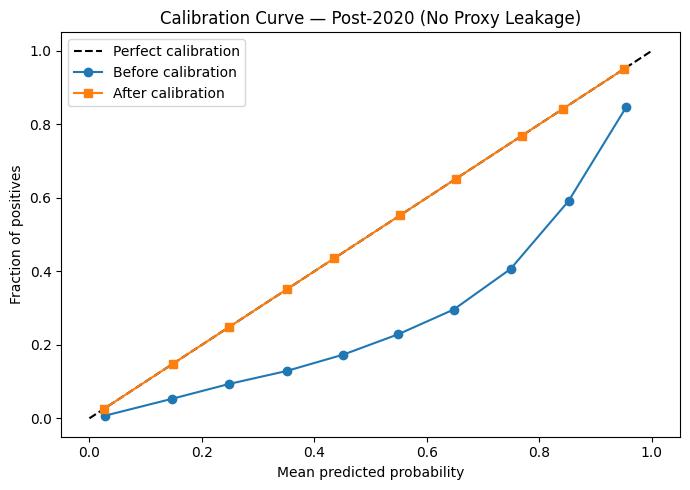

  Brier score (Before): 0.1435
  Brier score (After):  0.1002

[Stage 4] Applying calibrated model to Kazakhstan data...
  Final calibrated mean prediction for KZ: 0.2602


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


PROXY_COUNTRIES = ['Bulgaria', 'Turkey', 'Mexico', 'Estonia', 'Lithuania', 'Latvia']
TEMPORAL_CUTOFF = 2020

ANTIBIOTIC_TO_CLASS_MAP = {
    'Amikacin': 'Aminoglycosides',
    'Gentamicin': 'Aminoglycosides',
    'Imipenem': 'Carbapenems',
    'Meropenem': 'Carbapenems',
    'Cefepime': 'Cephalosporins',
    'Ceftazidime': 'Cephalosporins',
    'Ceftriaxone': 'Cephalosporins',
    'Ciprofloxacin': 'Fluoroquinolones',
    'Levofloxacin': 'Fluoroquinolones',
    'Amoxicillin- clavulanic acid': 'Penicillins',
    'Piperacillin tazobactam': 'Penicillins',
    'Colistin': 'Polymyxins',
    'Tigecycline': 'Tetracyclines',
    'Vancomycin': 'Glycopeptides',
    'Trimethoprim / sulfamethoxazole': 'Sulfonamides',
    'Linezolid': 'Oxazolidinones'
}

ANTIBIOTIC_TO_CLASS_MAP.update({k.lower(): v for k, v in list(ANTIBIOTIC_TO_CLASS_MAP.items())})

#Probability Calibration on Post-2020 Holdout
print("\n[Stage 3] Calibrating probabilities on post-2020 non-proxy holdout...")


cal_holdout_df = source_df[
    (source_df['year'] > TEMPORAL_CUTOFF) & 
    (~source_df['country'].isin(PROXY_COUNTRIES))
].copy()

print(f"  Calibration holdout: {len(cal_holdout_df):,} rows | "
      f"Countries: {cal_holdout_df['country'].nunique()}")

X_cal = get_X(cal_holdout_df)
y_cal = cal_holdout_df['resistance'].values

#raw probabilities
raw_probs = model_final.predict_proba(make_pool(cal_holdout_df))[:, 1]

#isotonic calibration
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(raw_probs, y_cal)

# Diagnostic Curve
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos_raw, mean_pred_raw = calibration_curve(y_cal, raw_probs, n_bins=10)
cal_probs_holdout = calibrator.predict(raw_probs)
frac_pos_cal, mean_pred_cal = calibration_curve(y_cal, cal_probs_holdout, n_bins=10)

ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_raw, frac_pos_raw, 'o-', label='Before calibration')
ax.plot(mean_pred_cal, frac_pos_cal, 's-', label='After calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — Post-2020 (No Proxy Leakage)')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/calibration_curve.png', dpi=150)
plt.show()


print(f"  Brier score (Before): {brier_score_loss(y_cal, raw_probs):.4f}")
print(f"  Brier score (After):  {brier_score_loss(y_cal, cal_probs_holdout):.4f}")


print("\n[Stage 4] Applying calibrated model to Kazakhstan data...")


kz_df['antibiotic'] = kz_df['antibiotic'].replace(antibiotic_harmonize)
kz_df['antibiotic'] = kz_df['antibiotic'].apply(lambda x: source_lower_map.get(x.lower().strip(), x))


kz_df['antibiotic_class'] = kz_df['antibiotic'].map(ANTIBIOTIC_TO_CLASS_MAP)
kz_df['antibiotic_class'] = kz_df.apply(
    lambda row: row['antibiotic_class']
    if pd.notna(row['antibiotic_class'])
    else ANTIBIOTIC_TO_CLASS_MAP.get(row['antibiotic'].lower().strip(), np.nan),
    axis=1
)


kz_pool        = make_pool(kz_df, has_labels=has_kz_labels)
y_kz_prob_raw  = model_final.predict_proba(kz_pool)[:, 1]
y_kz_prob      = calibrator.predict(y_kz_prob_raw)  


kz_pred_df = kz_df.copy()
kz_pred_df['pred_proba'] = y_kz_prob
kz_pred_df['pred_label'] = (y_kz_prob >= 0.5).astype(int)

print(f"  Final calibrated mean prediction for KZ: {y_kz_prob.mean():.4f}")
kz_pred_df.to_csv('/kaggle/working/kz_predictions_calibrated.csv', index=False)

In [25]:

print(f"Holdout resistance prevalence: {y_cal.mean():.3f}")


print(f"Raw KZ mean    : {y_kz_prob_raw.mean():.4f}")
print(f"Calibrated mean: {y_kz_prob.mean():.4f}")


print(cal_holdout_df['country'].value_counts().head(10))

Holdout resistance prevalence: 0.197
Raw KZ mean    : 0.4917
Calibrated mean: 0.2602
country
USA        525568
China      172986
Italy      114535
Spain      113861
France     111088
India      110824
Germany     97975
Canada      73840
Brazil      60683
Belgium     55048
Name: count, dtype: int64


In [26]:
from sklearn.linear_model import LogisticRegression
calibrator_platt = LogisticRegression()
calibrator_platt.fit(raw_probs.reshape(-1, 1), y_cal)
y_kz_prob = calibrator_platt.predict_proba(y_kz_prob_raw.reshape(-1, 1))[:, 1]
print(f"Platt calibrated mean: {y_kz_prob.mean():.4f}")

Platt calibrated mean: 0.2689


**Brier Analysis on Kazakhstan**

In [20]:
import pandas as pd



data = [
    # Acinetobacter baumannii
    ['Acinetobacter baumannii', 'Carbapenems', 'Meropenem, Imipenem', '81.0 – 92.0', None],
    ['Acinetobacter baumannii', 'Fluoroquinolones', 'Ciprofloxacin', '89.3', None],
    ['Acinetobacter baumannii', 'Aminoglycosides', 'Amikacin, Gentamicin', '65.2 – 79.9', None],
    
    # Escherichia coli
    ['Escherichia coli', 'Cephalosporins', '3rd generation (Ceftriaxone, Cefotaxime)', '65.0 – 70.0', None],
    ['Escherichia coli', 'Fluoroquinolones', 'Ciprofloxacin, Levofloxacin', '63.0', None],
    ['Escherichia coli', 'Penicillins', 'Piperacillin', '75.2', None],
    ['Escherichia coli', 'Aminoglycosides', 'Gentamicin, Tobramycin', '11.0 – 59.1', None],
    ['Escherichia coli', 'Tetracyclines', 'Tetracycline', '16.0 – 25.6', None],
    
    # Klebsiella pneumoniae
    ['Klebsiella pneumoniae', 'Carbapenems', 'Meropenem, Imipenem, Ertapenem', '15.0 – 35.0', None],
    ['Klebsiella pneumoniae', 'Fluoroquinolones', 'Ciprofloxacin, Levofloxacin', '17.0 – 84.0', None],
    ['Klebsiella pneumoniae', 'Cephalosporins', '3rd generation (Ceftriaxone, Cefotaxime)', '18.0 – 76.0', None],
    
    # Staphylococcus aureus
    ['Staphylococcus aureus', 'Penicillins', 'Methicillin (MRSA)', '12.5 – 45.0', None],
    ['Staphylococcus aureus', 'Macrolides', 'Azithromycin, Erythromycin', '58.0', None],
    ['Staphylococcus aureus', 'Fluoroquinolones', 'Ciprofloxacin', '21.0', None],
    ['Staphylococcus aureus', 'Cephalosporins', 'Cefazolin', '21.0', None],
    
    # Pseudomonas aeruginosa
    ['Pseudomonas aeruginosa', 'Carbapenems', 'Meropenem, Imipenem', '27.0', None],
    ['Pseudomonas aeruginosa', 'Fluoroquinolones', 'Ciprofloxacin, Levofloxacin', '60.0', None],
    
    # Streptococcus pneumoniae
    ['Streptococcus pneumoniae', 'Penicillins', 'Penicillin G', '32.0', None],
    ['Streptococcus pneumoniae', 'Macrolides', 'Azithromycin, Erythromycin', '39.0', None],
    ['Streptococcus pneumoniae', 'Sulfonamides', 'Trimethoprim/Sulfamethoxazole', '42.0', None],
    
    # Enterobacter spp.
    ['Enterobacter spp.', 'Cephalosporins', '3rd/4th generation', '53.0', None],
    ['Enterobacter spp.', 'Fluoroquinolones', 'Ciprofloxacin', '44.0', None],
]

columns = ['organism', 'antibiotic_class', 'specific_antibiotic', 'resistance_percent', 'source']

kz_truth = pd.DataFrame(data, columns=columns)

def extract_midpoint(val):
    if isinstance(val, str) and '–' in val:
        parts = val.replace(' ', '').split('–')
        return (float(parts[0]) + float(parts[1])) / 2
    return float(val) if val is not None else None

kz_truth['resistance_midpoint'] = kz_truth['resistance_percent'].apply(extract_midpoint)


kz_truth.to_csv('/kaggle/working/kz_ground_truth.csv', index=False)

print("kz_truth created successfully!")
print(f"Shape: {kz_truth.shape}")
print("\nPreview:")
print(kz_truth.head(10))

kz_truth created successfully!
Shape: (22, 6)

Preview:
                  organism  antibiotic_class  \
0  Acinetobacter baumannii       Carbapenems   
1  Acinetobacter baumannii  Fluoroquinolones   
2  Acinetobacter baumannii   Aminoglycosides   
3         Escherichia coli    Cephalosporins   
4         Escherichia coli  Fluoroquinolones   
5         Escherichia coli       Penicillins   
6         Escherichia coli   Aminoglycosides   
7         Escherichia coli     Tetracyclines   
8    Klebsiella pneumoniae       Carbapenems   
9    Klebsiella pneumoniae  Fluoroquinolones   

                        specific_antibiotic resistance_percent source  \
0                       Meropenem, Imipenem        81.0 – 92.0   None   
1                             Ciprofloxacin               89.3   None   
2                      Amikacin, Gentamicin        65.2 – 79.9   None   
3  3rd generation (Ceftriaxone, Cefotaxime)        65.0 – 70.0   None   
4               Ciprofloxacin, Levofloxacin       

In [ ]:
# =============================================================================
# ABLATION STUDY — Retrain without feature groups + individual features
# =============================================================================

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, brier_score_loss
)
import os

print("=== Ablation Study — CatBoost Feature Groups ===")

# ── Load data ─────────────────────────────────────────────────────────────────
full_df = pd.read_csv('/kaggle/input/datasets/david0913/full-df/full_amr_with_macro.csv',
                      low_memory=False)

EXCLUDE_COUNTRIES = ['Kazakhstan', 'Russia', 'Belarus', 'Ukraine']
TEMPORAL_CUTOFF   = 2020
ES_VAL_YEARS      = [2019, 2020]

source_df = full_df[~full_df['country'].isin(EXCLUDE_COUNTRIES)].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

y_source         = source_df['resistance'].values
SCALE_POS_WEIGHT = (y_source == 0).sum() / (y_source == 1).sum()

# ── Define feature groups ─────────────────────────────────────────────────────
CONSUMPTION_FEATURES = ['log_consumption_ddd', 'log_consumption_did_per_class']
MACRO_FEATURES       = ['log_gdp_per_capita', 'health_expenditure_pct_gdp',
                         'population_density_per_sq_km']
ALL_CONTEXTUAL       = CONSUMPTION_FEATURES + MACRO_FEATURES

# Ablation configs: name → features to REMOVE
ABLATION_CONFIGS = {
    'full_model':               [],                    # baseline — nothing removed
    'no_consumption':           CONSUMPTION_FEATURES,
    'no_macro':                 MACRO_FEATURES,
    'no_contextual':            ALL_CONTEXTUAL,
}

# Add individual feature ablations
for f in ALL_CONTEXTUAL:
    ABLATION_CONFIGS[f'no_{f}'] = [f]

print(f"Ablation configs: {list(ABLATION_CONFIGS.keys())}")

# ── Temporal splits ───────────────────────────────────────────────────────────
es_val_df   = source_df[source_df['year'].isin(ES_VAL_YEARS)].copy()
es_train_df = source_df[
    (source_df['year'] <= TEMPORAL_CUTOFF) &
    (~source_df['year'].isin(ES_VAL_YEARS))
].copy()
test_df = source_df[source_df['year'] > TEMPORAL_CUTOFF].copy()

print(f"ES train: {len(es_train_df):,} | ES val: {len(es_val_df):,} | Test: {len(test_df):,}")

# ── CatBoost params ───────────────────────────────────────────────────────────
BASE_PARAMS = {
    'learning_rate':         0.03,
    'depth':                 7,
    'reg_lambda':            3,
    'eval_metric':           'AUC',
    'random_seed':           42,
    'verbose':               0,
    'early_stopping_rounds': 100,
    'iterations':            5000,
    'task_type':             'GPU',
    'scale_pos_weight':      SCALE_POS_WEIGHT,
}

# ── Helper ────────────────────────────────────────────────────────────────────
def make_pool_ablated(df, features, cat_features, has_labels=True):
    X = df[features].copy()
    for col in cat_features:
        if col in X.columns:
            X[col] = X[col].fillna('unknown').astype(str)
    if has_labels:
        return Pool(data=X, label=df['resistance'].values, cat_features=cat_features)
    return Pool(data=X, cat_features=cat_features)

def evaluate(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'AUC':   roc_auc_score(y_true, y_prob)            if y_true.std() > 0 else np.nan,
        'AUPRC': average_precision_score(y_true, y_prob)  if y_true.std() > 0 else np.nan,
        'F1':    f1_score(y_true, y_pred, zero_division=0),
        'Brier': brier_score_loss(y_true, y_prob),
    }

# ── Run ablations ─────────────────────────────────────────────────────────────
ablation_results = []

for config_name, remove_features in ABLATION_CONFIGS.items():
    print(f"\n→ Running: {config_name} (removing: {remove_features if remove_features else 'nothing'})")

    # Build feature list for this config
    ablated_features  = [f for f in FEATURES if f not in remove_features]
    ablated_cat_feats = [f for f in CAT_FEATURES if f not in remove_features]

    if len(ablated_features) == 0:
        print("  Skipped — no features left")
        continue

    # Stage 1 — calibrate iterations
    cal_model = CatBoostClassifier(**BASE_PARAMS)
    cal_model.fit(
        make_pool_ablated(es_train_df, ablated_features, ablated_cat_feats),
        eval_set=make_pool_ablated(es_val_df, ablated_features, ablated_cat_feats),
    )
    best_iter = cal_model.best_iteration_

    # Stage 2 — retrain on full ≤ 2020 data
    final_train_df = source_df[source_df['year'] <= TEMPORAL_CUTOFF].copy()
    final_params   = {**BASE_PARAMS,
                      'iterations': best_iter,
                      'early_stopping_rounds': None,
                      'verbose': 0}

    model_abl = CatBoostClassifier(**final_params)
    model_abl.fit(make_pool_ablated(final_train_df, ablated_features, ablated_cat_feats))

    # Evaluate on test set
    y_prob = model_abl.predict_proba(
        make_pool_ablated(test_df, ablated_features, ablated_cat_feats)
    )[:, 1]
    y_true = test_df['resistance'].values

    metrics = evaluate(y_true, y_prob)
    metrics['config']          = config_name
    metrics['removed_features'] = ', '.join(remove_features) if remove_features else 'none'
    metrics['n_features']      = len(ablated_features)
    metrics['best_iter']       = best_iter
    ablation_results.append(metrics)

    print(f"  AUC={metrics['AUC']:.4f} | AUPRC={metrics['AUPRC']:.4f} | "
          f"F1={metrics['F1']:.4f} | Brier={metrics['Brier']:.4f} | iter={best_iter}")

# ── Results table ─────────────────────────────────────────────────────────────
ablation_df = pd.DataFrame(ablation_results)[
    ['config', 'removed_features', 'n_features',
     'AUC', 'AUPRC', 'F1', 'Brier', 'best_iter']
].sort_values('AUC', ascending=False)

# Compute delta vs full model
baseline = ablation_df[ablation_df['config'] == 'full_model'].iloc[0]
for metric in ['AUC', 'AUPRC', 'F1', 'Brier']:
    ablation_df[f'Δ{metric}'] = (ablation_df[metric] - baseline[metric]).round(4)

print(f"\n{'='*70}")
print("ABLATION RESULTS (sorted by AUC):")
print(ablation_df.to_string(index=False))

os.makedirs('/kaggle/working', exist_ok=True)
ablation_df.to_csv('/kaggle/working/ablation_results.csv', index=False)
print("\n✅ Saved ablation_results.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
metrics_to_plot = ['AUC', 'AUPRC', 'F1', 'Brier']
colors = ['#d62728' if c == 'full_model' else '#1f77b4'
          for c in ablation_df['config']]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(ablation_df['config'], ablation_df[metric], color=colors)
    ax.axvline(baseline[metric], color='red', linestyle='--', linewidth=1.5,
               label='Baseline')
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    if metric == 'Brier':
        ax.set_xlabel('Brier (lower=better)')

axes[0].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved ablation_plot.png")

=== Ablation Study — CatBoost Feature Groups ===
Ablation configs: ['full_model', 'no_consumption', 'no_macro', 'no_contextual', 'no_log_consumption_ddd', 'no_log_consumption_did_per_class', 'no_log_gdp_per_capita', 'no_health_expenditure_pct_gdp', 'no_population_density_per_sq_km']
ES train: 7,670,980 | ES val: 1,754,481 | Test: 2,657,407

→ Running: full_model (removing: nothing)


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


  AUC=0.8783 | AUPRC=0.6923 | F1=0.5901 | Brier=0.1445 | iter=2330

→ Running: no_consumption (removing: ['log_consumption_ddd', 'log_consumption_did_per_class'])


Default metric period is 5 because AUC is/are not implemented for GPU
